# Measuring the Impact of Weather on Public Transport in Dublin

**Programming for Data Analytics — CA2**

---

## 1. Introduction

This notebook investigates how weather conditions influence public transport usage in Dublin, Ireland. By combining meteorological records from **Met Éireann** with passenger statistics published by the **Central Statistics Office (CSO)** and **Transport Infrastructure Ireland (TII)**, we build a data-driven picture of urban mobility under varying weather conditions.

### 1.1 Research Questions

1. Do rainy months drive more people onto buses and trams?
2. How does temperature correlate with monthly and weekly ridership?
3. Are there day-of-week differences in how weather affects Luas usage?
4. What seasonal patterns emerge when weather and transport are overlaid?
5. How did COVID-19 disrupt these weather–transport relationships?

### 1.2 Datasets

| # | Dataset | Source | Granularity | Rows | Key Fields |
|---|---------|--------|-------------|------|------------|
| 1 | Dublin Airport Hourly Weather | Met Éireann | Hourly | ~700 k | temp, rain, rhum, wdsp, sun, vis |
| 2 | Dublin Airport Daily Weather | Met Éireann | Daily | ~30 k | rain, maxtp, mintp, wdsp, sun |
| 3 | Dublin Airport Monthly Weather | Met Éireann | Monthly | ~1 k | rain, meant, mnmax, mnmin, sun |
| 4 | Weekly Passenger Journeys (THA25) | CSO | Weekly | ~1.5 k | Dublin Metro Bus, Bus excl. Dublin, Rail |
| 5 | Dublin Bus Monthly Passengers (TOA14) | CSO | Monthly | ~130 | passenger counts 2014–2024 |
| 6 | Luas Monthly Passengers (TOA11) | CSO | Monthly | ~270 | Red / Green line, 2018–2024 |
| 7 | Luas Hourly Distribution (TOA09) | CSO | Hourly % | ~360 | % of daily pax by hour & line |
| 8 | Luas Average Weekly Flow (TOA02) | CSO | Day-of-week | ~170 | avg daily pax by weekday |
| 9 | Dublin Bus Fleet (TOA13) | CSO | Yearly | ~400 | fleet size by depot & type |
| 10 | Bus City Routes (TOA15) | CSO | Day-of-week | ~240 | avg weekly pax by city |
| 11 | Rail Network (TOA10) | CSO | Yearly | ~155 | line length, stops |

All data is openly licensed (Creative Commons Attribution 4.0).

## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro, f_oneway, kruskal
import warnings, textwrap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (15, 6), 'figure.dpi': 110,
                      'axes.titlesize': 13, 'axes.labelsize': 11})

DATA = 'data/'
print('Libraries loaded.')

Libraries loaded.


## 3. Data Loading & Cleaning

Each dataset is loaded, parsed, and enriched with helper columns (year, month, season, etc.).

### 3.1 Met Éireann — Daily Weather (primary weather source)

In [2]:
weather_daily = pd.read_csv(f'{DATA}met_eireann_dublin_daily.csv', skiprows=24)
weather_daily.columns = weather_daily.columns.str.strip()
weather_daily['date'] = pd.to_datetime(weather_daily['date'], format='%d-%b-%Y')

num_cols_d = ['maxtp','mintp','rain','wdsp','sun','gmin','soil','hg','cbl']
for c in num_cols_d:
    if c in weather_daily.columns:
        weather_daily[c] = pd.to_numeric(weather_daily[c].astype(str).str.strip(), errors='coerce')

weather_daily['year']  = weather_daily['date'].dt.year
weather_daily['month'] = weather_daily['date'].dt.month
weather_daily['week']  = weather_daily['date'].dt.isocalendar().week.astype(int)
weather_daily['dow']   = weather_daily['date'].dt.day_name()
weather_daily['avg_temp'] = (weather_daily['maxtp'] + weather_daily['mintp']) / 2
weather_daily['is_rainy'] = weather_daily['rain'] > 0.2
weather_daily['rain_cat'] = pd.cut(weather_daily['rain'],
    bins=[-0.1, 0, 1, 5, 20, 200],
    labels=['Dry','Light','Moderate','Heavy','Very Heavy'])
season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}
weather_daily['season'] = weather_daily['month'].map(season_map)

print(f"Daily weather: {weather_daily.shape}  |  {weather_daily['date'].min().date()} → {weather_daily['date'].max().date()}")
weather_daily[['date','rain','maxtp','mintp','avg_temp','wdsp','sun','season']].describe().round(2)

Daily weather: (30740, 34)  |  1942-01-01 → 2026-02-28


,date,rain,maxtp,mintp,avg_temp,wdsp,sun
count,30740,30740.00,30740.00,30740.00,30740.00,30740.00,30740.00
mean,1984-01-30 12:00:00,2.08,13.08,6.16,9.62,10.17,4.01
min,1942-01-01 00:00:00,0.00,-4.70,-12.20,-8.05,0.00,0.00
25%,1963-01-15 18:00:00,0.00,9.40,2.90,6.25,6.80,0.50
50%,1984-01-30 12:00:00,0.20,13.00,6.30,9.60,9.50,3.20
75%,2005-02-13 06:00:00,2.20,16.90,9.60,13.15,13.00,6.50
max,2026-02-28 00:00:00,92.60,29.10,18.40,22.45,35.50,15.90
std,NaN,4.40,4.91,4.38,4.46,4.58,3.76


### 3.2 Met Éireann — Monthly Weather

In [3]:
weather_monthly = pd.read_csv(f'{DATA}met_eireann_dublin_monthly.csv', skiprows=19)
weather_monthly.columns = weather_monthly.columns.str.strip()

for c in ['meant','maxtp','mintp','mnmax','mnmin','rain','gmin','wdsp','maxgt','sun']:
    if c in weather_monthly.columns:
        weather_monthly[c] = pd.to_numeric(weather_monthly[c].astype(str).str.strip(), errors='coerce')

weather_monthly['year']  = weather_monthly['year'].astype(int)
weather_monthly['month'] = weather_monthly['month'].astype(int)
weather_monthly['date']  = pd.to_datetime(weather_monthly['year'].astype(str) + '-' +
                                           weather_monthly['month'].astype(str) + '-01')
weather_monthly['season'] = weather_monthly['month'].map(season_map)

print(f"Monthly weather: {weather_monthly.shape}  |  {weather_monthly['date'].min().date()} → {weather_monthly['date'].max().date()}")
weather_monthly.tail()

Monthly weather: (1011, 14)  |  1941-11-01 → 2026-01-01


,year,month,meant,maxtp,mintp,mnmax,mnmin,rain,gmin,wdsp,maxgt,sun,date,season
1006,2025,9,12.7,20.0,1.8,16.7,8.7,91.4,-2.1,8.2,42.0,130.6,2025-09-01,Autumn
1007,2025,10,11.2,19.7,3.0,13.8,8.6,90.0,-1.7,9.6,48.0,69.4,2025-10-01,Autumn
1008,2025,11,8.2,17.4,-2.3,11.3,5.1,119.1,-4.5,9.6,50.0,91.7,2025-11-01,Autumn
1009,2025,12,7.4,16.3,0.0,9.7,5.0,48.4,-4.6,10.1,52.0,59.3,2025-12-01,Winter
1010,2026,1,4.6,12.8,-3.9,7.2,1.9,137.7,-7.7,10.5,47.0,63.0,2026-01-01,Winter


### 3.3 Hourly Weather (sample for peak-hour analysis)

In [4]:
# Only load 2019-2025 range (matching transport data) to keep memory low
weather_hourly_raw = pd.read_csv(f'{DATA}met_eireann_dublin_hourly.csv', skiprows=22)
weather_hourly_raw.columns = weather_hourly_raw.columns.str.strip()
weather_hourly_raw['date'] = pd.to_datetime(weather_hourly_raw['date'], format='%d-%b-%Y %H:%M', errors='coerce')
weather_hourly = weather_hourly_raw[weather_hourly_raw['date'].dt.year >= 2018].copy()

for c in ['rain','temp','rhum','wdsp','sun','vis']:
    if c in weather_hourly.columns:
        weather_hourly[c] = pd.to_numeric(weather_hourly[c].astype(str).str.strip(), errors='coerce')

weather_hourly['hour'] = weather_hourly['date'].dt.hour
weather_hourly['year'] = weather_hourly['date'].dt.year
weather_hourly['month'] = weather_hourly['date'].dt.month

del weather_hourly_raw  # free memory

print(f"Hourly weather (2018+): {weather_hourly.shape}")
weather_hourly[['date','rain','temp','rhum','wdsp','sun','vis']].describe().round(2)

Hourly weather (2018+): (71545, 24)


,date,rain,temp,rhum,wdsp,sun,vis
count,71545,71545.00,71545.00,71545.00,71545.00,71545.00,71539.00
mean,2022-01-30 12:00:00,0.09,10.14,81.73,9.20,0.17,26288.38
min,2018-01-01 00:00:00,0.00,-5.60,24.00,0.00,0.00,100.00
25%,2020-01-16 06:00:00,0.00,6.60,74.00,6.00,0.00,20000.00
50%,2022-01-30 12:00:00,0.00,10.10,84.00,9.00,0.00,25000.00
75%,2024-02-14 18:00:00,0.00,13.80,91.00,12.00,0.10,30000.00
max,2026-03-01 00:00:00,13.80,29.10,100.00,42.00,1.00,75000.00
std,NaN,0.42,5.07,12.02,4.52,0.32,12362.35


### 3.4 Transport Datasets

In [5]:
# ---- Dublin Bus Monthly (TOA14) ----
bus_raw = pd.read_csv(f'{DATA}dublin_bus_monthly_passengers.csv')
bus = bus_raw[bus_raw['Month'] != 'All months'].copy()
bus['passengers'] = pd.to_numeric(bus['VALUE'], errors='coerce')
bus['year']  = bus['Year'].astype(int)
bus['month'] = bus['C01885V02316'].astype(int)
bus['date']  = pd.to_datetime(bus['year'].astype(str)+'-'+bus['month'].astype(str)+'-01')
bus['season'] = bus['month'].map(season_map)

# ---- Luas Monthly (TOA11) ----
luas_raw = pd.read_csv(f'{DATA}luas_passenger_numbers.csv')
luas = luas_raw[luas_raw['Month'] != 'All months'].copy()
luas['passengers'] = pd.to_numeric(luas['VALUE'], errors='coerce')
luas['year']  = luas['Year'].astype(int)
luas['month'] = luas['C01885V02316'].astype(int)
luas['line']  = luas['Statistic Label']
luas['date']  = pd.to_datetime(luas['year'].astype(str)+'-'+luas['month'].astype(str)+'-01')
luas['season'] = luas['month'].map(season_map)
luas_total = luas.groupby(['date','year','month','season']).agg(passengers=('passengers','sum')).reset_index()

# ---- Weekly passenger journeys (THA25) ----
weekly = pd.read_csv(f'{DATA}weekly_passenger_journeys.csv')
weekly['passengers'] = pd.to_numeric(weekly['VALUE'], errors='coerce')
weekly['mode'] = weekly['Mode of Transport']
weekly['year'] = weekly['Week'].str[:4].astype(int)
weekly['week_num'] = weekly['Week'].str.extract(r'Week (\d+)').astype(float).astype('Int64')
# Build a date from ISO year + week
weekly['date'] = pd.to_datetime(weekly['TLIST(W1)'] + '1', format='%GW%V%u', errors='coerce')
weekly['month'] = weekly['date'].dt.month
weekly['season'] = weekly['month'].map(season_map)

# ---- Luas hourly % (TOA09) ----
luas_hr = pd.read_csv(f'{DATA}luas_hourly_passengers.csv')
luas_hr['pct']  = pd.to_numeric(luas_hr['VALUE'], errors='coerce')
luas_hr['year'] = luas_hr['Year'].astype(int)
luas_hr['line'] = luas_hr['Luas Line']
luas_hr['hour'] = luas_hr['Time of day'].str.extract(r'(\d{2})').astype(float)

# ---- Luas day-of-week flow (TOA02) ----
luas_dow = pd.read_csv(f'{DATA}luas_weekly_passengers.csv')
luas_dow['flow'] = pd.to_numeric(luas_dow['VALUE'], errors='coerce')
luas_dow['year'] = luas_dow['Year'].astype(int)
luas_dow['day']  = luas_dow['Days of Week']
luas_dow['line_label'] = luas_dow['Statistic Label']

# ---- Bus routes (TOA15) ----
bus_routes = pd.read_csv(f'{DATA}bus_routes.csv')
bus_routes['flow'] = pd.to_numeric(bus_routes['VALUE'], errors='coerce')
bus_routes['year'] = bus_routes['Year'].astype(int)
bus_routes['city'] = bus_routes['Bus City Services']
bus_routes['day']  = bus_routes['Day of Week']

print('All transport datasets loaded.')
print(f'  Dublin Bus monthly : {bus.shape[0]} rows  ({bus["year"].min()}–{bus["year"].max()})')
print(f'  Luas monthly       : {luas.shape[0]} rows  ({luas["year"].min()}–{luas["year"].max()})')
print(f'  Weekly journeys    : {weekly.shape[0]} rows  ({weekly["year"].min()}–{weekly["year"].max()})')
print(f'  Luas hourly %      : {luas_hr.shape[0]} rows  ({luas_hr["year"].min()}–{luas_hr["year"].max()})')
print(f'  Luas day-of-week   : {luas_dow.shape[0]} rows  ({luas_dow["year"].min()}–{luas_dow["year"].max()})')
print(f'  Bus routes/cities  : {bus_routes.shape[0]} rows  ({bus_routes["year"].min()}–{bus_routes["year"].max()})')

All transport datasets loaded.
  Dublin Bus monthly : 132 rows  (2014–2024)
  Luas monthly       : 252 rows  (2018–2024)
  Weekly journeys    : 1488 rows  (2019–2026)
  Luas hourly %      : 360 rows  (2019–2024)
  Luas day-of-week   : 168 rows  (2018–2024)
  Bus routes/cities  : 240 rows  (2018–2023)


### 3.5 Data Quality Overview

In [6]:
datasets = {
    'Daily Weather': weather_daily[['rain','maxtp','mintp','wdsp','sun']],
    'Monthly Weather': weather_monthly[['rain','meant','mnmax','mnmin','sun']],
    'Hourly Weather': weather_hourly[['rain','temp','rhum','wdsp','sun']],
    'Bus Monthly': bus[['passengers']],
    'Luas Monthly': luas[['passengers']],
    'Weekly Journeys': weekly[['passengers']],
}

quality = []
for name, df in datasets.items():
    total = len(df)
    missing = df.isnull().sum().sum()
    pct = (missing / (total * len(df.columns))) * 100 if total > 0 else 0
    quality.append({'Dataset': name, 'Rows': total, 'Columns': len(df.columns),
                    'Total Missing': missing, 'Missing %': round(pct, 2)})

quality_df = pd.DataFrame(quality)
print(quality_df.to_string(index=False))

        Dataset  Rows  Columns  Total Missing  Missing %
  Daily Weather 30740        5              0        0.0
Monthly Weather  1011        5              0        0.0
 Hourly Weather 71545        5              0        0.0
    Bus Monthly   132        1              0        0.0
   Luas Monthly   252        1              0        0.0
Weekly Journeys  1488        1             64        4.3


## 4. Dublin Weather Profile

Before looking at transport, we first characterise Dublin's climate to contextualise the patterns.

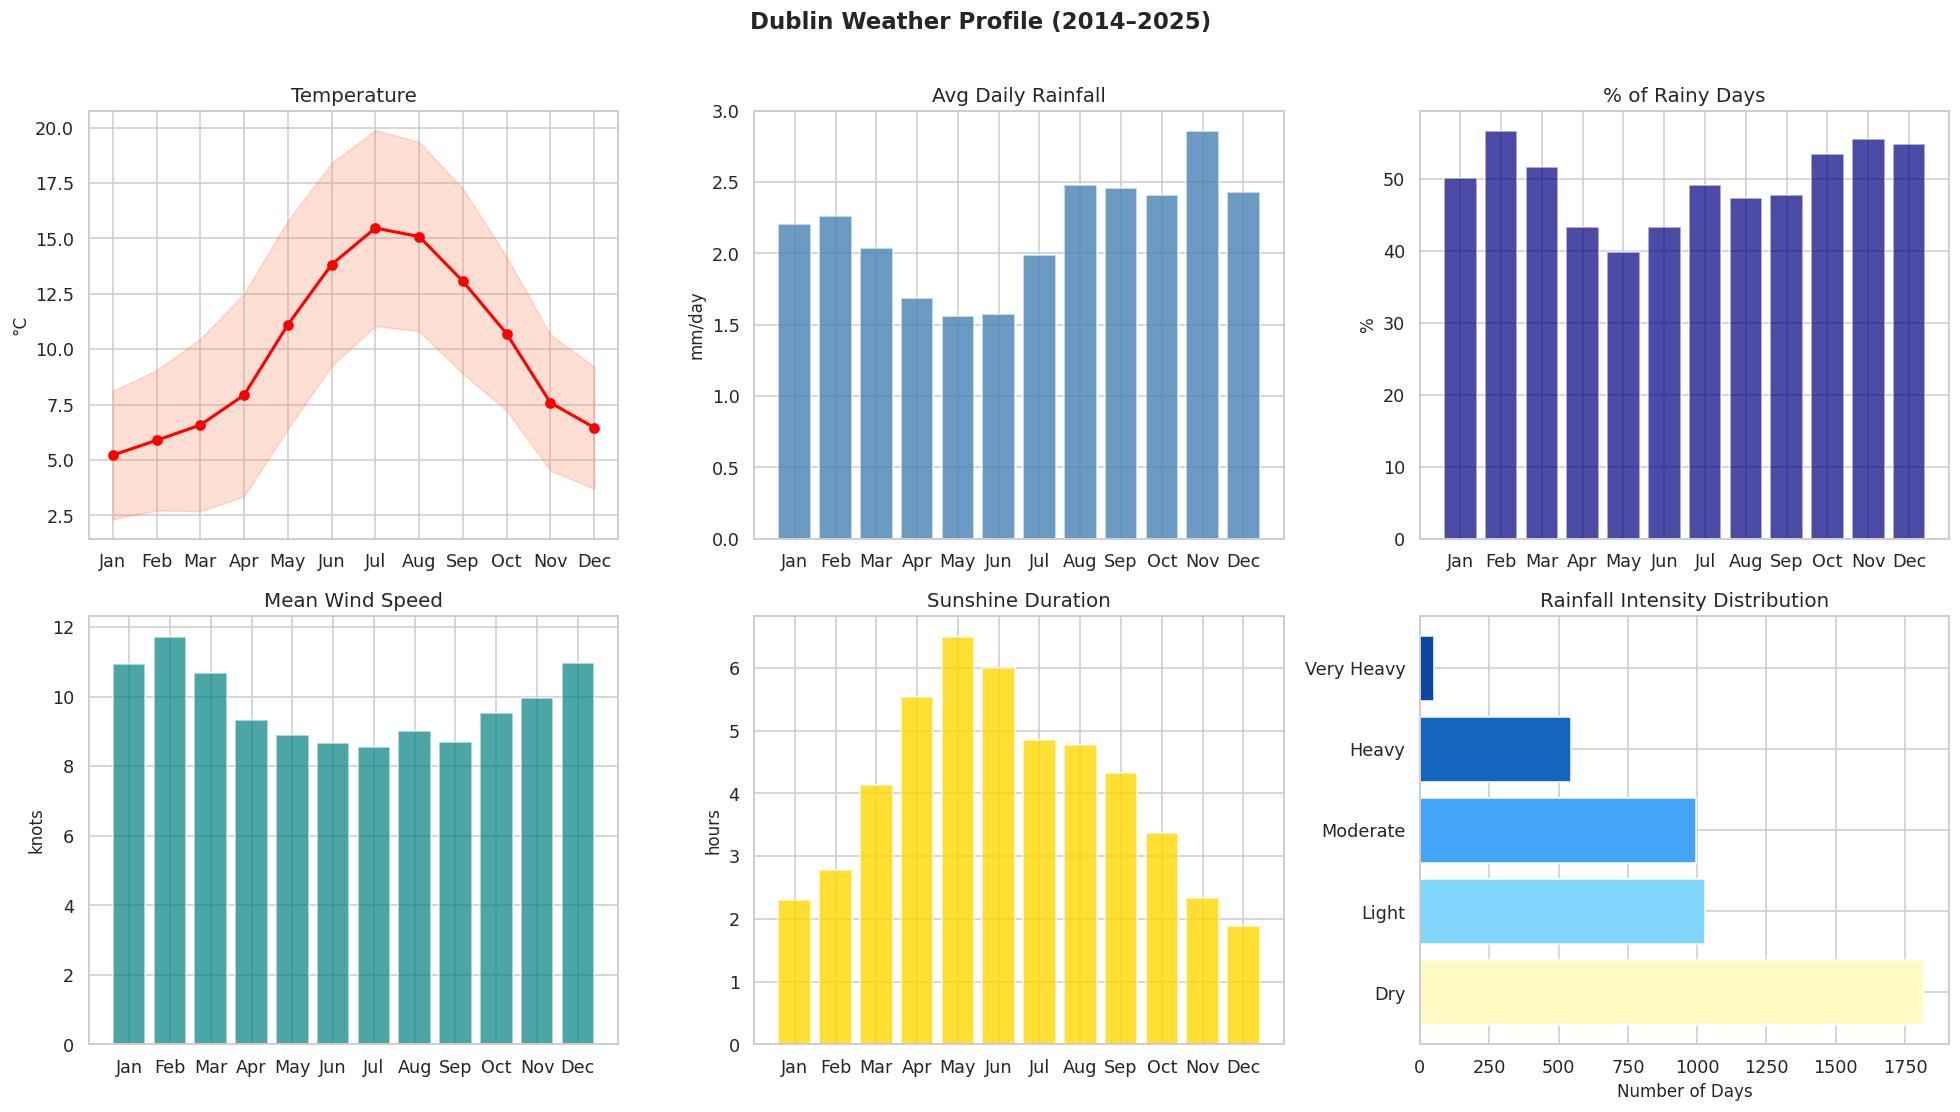

In [7]:
wd = weather_daily[weather_daily['year'] >= 2014].copy()

mo_avg = wd.groupby('month').agg(
    rain=('rain','mean'), max_t=('maxtp','mean'), min_t=('mintp','mean'),
    avg_t=('avg_temp','mean'), wind=('wdsp','mean'), sun=('sun','mean'),
    rainy_pct=('is_rainy','mean')
).reset_index()
mn = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Temperature
ax = axes[0,0]
ax.fill_between(range(12), mo_avg['min_t'], mo_avg['max_t'], alpha=0.25, color='coral')
ax.plot(range(12), mo_avg['avg_t'], 'o-', color='red', lw=2)
ax.set(xticks=range(12), ylabel='°C', title='Temperature'); ax.set_xticklabels(mn)

# Rainfall
ax = axes[0,1]
ax.bar(range(12), mo_avg['rain'], color='steelblue', alpha=0.8)
ax.set(xticks=range(12), ylabel='mm/day', title='Avg Daily Rainfall'); ax.set_xticklabels(mn)

# Rainy days %
ax = axes[0,2]
ax.bar(range(12), mo_avg['rainy_pct']*100, color='navy', alpha=0.7)
ax.set(xticks=range(12), ylabel='%', title='% of Rainy Days'); ax.set_xticklabels(mn)

# Wind
ax = axes[1,0]
ax.bar(range(12), mo_avg['wind'], color='teal', alpha=0.7)
ax.set(xticks=range(12), ylabel='knots', title='Mean Wind Speed'); ax.set_xticklabels(mn)

# Sunshine
ax = axes[1,1]
ax.bar(range(12), mo_avg['sun'], color='gold', alpha=0.8)
ax.set(xticks=range(12), ylabel='hours', title='Sunshine Duration'); ax.set_xticklabels(mn)

# Rain distribution
ax = axes[1,2]
cats = wd['rain_cat'].value_counts().reindex(['Dry','Light','Moderate','Heavy','Very Heavy'])
ax.barh(cats.index, cats.values, color=['#FFF9C4','#81D4FA','#42A5F5','#1565C0','#0D47A1'])
ax.set(xlabel='Number of Days', title='Rainfall Intensity Distribution')

fig.suptitle('Dublin Weather Profile (2014–2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Transport Trends Overview

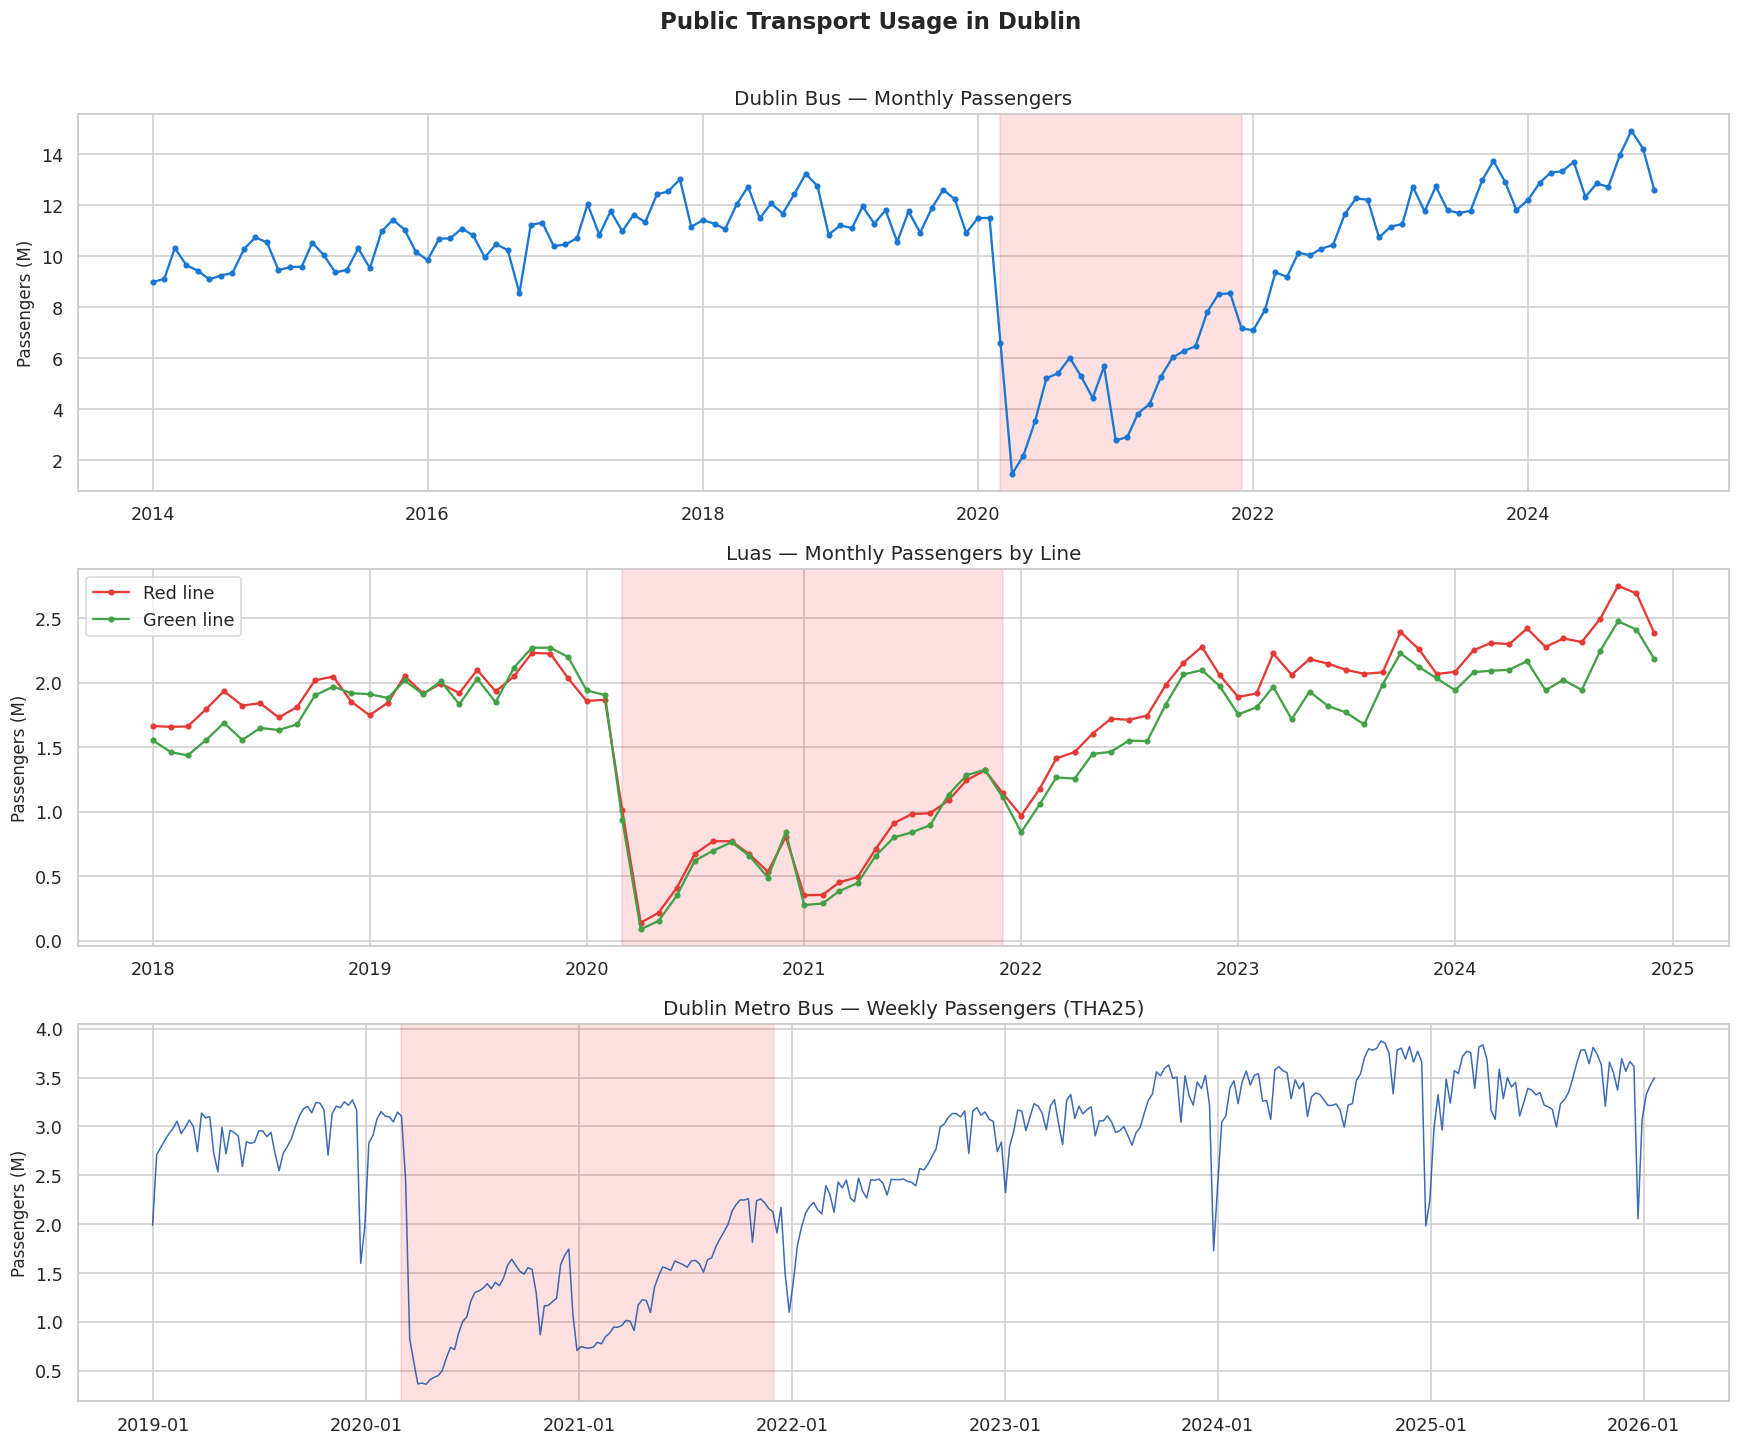

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)

# 5a — Dublin Bus monthly
ax = axes[0]
ax.plot(bus['date'], bus['passengers']/1e6, 'o-', ms=3, color='#1976D2', lw=1.5)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), alpha=0.12, color='red')
ax.set(ylabel='Passengers (M)', title='Dublin Bus — Monthly Passengers')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 5b — Luas by line
ax = axes[1]
for ln, clr in [('Red line','#E53935'),('Green line','#43A047')]:
    d = luas[luas['line']==ln]
    ax.plot(d['date'], d['passengers']/1e6, 'o-', ms=3, color=clr, lw=1.5, label=ln)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), alpha=0.12, color='red')
ax.set(ylabel='Passengers (M)', title='Luas — Monthly Passengers by Line')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 5c — Weekly journeys (Dublin Metro Bus)
ax = axes[2]
wk_bus = weekly[weekly['mode']=='Dublin Metro Bus'].dropna(subset=['passengers','date']).sort_values('date')
ax.plot(wk_bus['date'], wk_bus['passengers']/1e6, '-', color='#0D47A1', lw=1, alpha=0.8)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), alpha=0.12, color='red')
ax.set(ylabel='Passengers (M)', title='Dublin Metro Bus — Weekly Passengers (THA25)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle('Public Transport Usage in Dublin', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Weather × Transport — Monthly Correlation

We merge monthly weather with monthly transport data and compute correlations. COVID years (2020–2021) are excluded to avoid masking weather effects with pandemic disruptions.

In [9]:
# Merge weather_monthly with bus
bw = bus.merge(weather_monthly[['year','month','rain','meant','mnmax','mnmin','wdsp','sun']],
               on=['year','month'], how='inner')
bw_nc = bw[~bw['year'].isin([2020, 2021])]

# Merge weather_monthly with luas_total
lw = luas_total.merge(weather_monthly[['year','month','rain','meant','mnmax','mnmin','wdsp','sun']],
                      on=['year','month'], how='inner')
lw_nc = lw[~lw['year'].isin([2020, 2021])]

print(f'Bus+Weather (no COVID): {bw_nc.shape[0]} months')
print(f'Luas+Weather (no COVID): {lw_nc.shape[0]} months')

Bus+Weather (no COVID): 108 months
Luas+Weather (no COVID): 60 months


In [10]:
def corr_table(df, pax_col='passengers'):
    """Compute Pearson & Spearman correlations between weather variables and passengers."""
    weather_vars = {'rain':'Rainfall (mm)','meant':'Mean Temp (°C)',
                    'wdsp':'Wind Speed (kt)','sun':'Sunshine (hrs)'}
    rows = []
    for col, label in weather_vars.items():
        valid = df.dropna(subset=[col, pax_col])
        if len(valid) < 5: continue
        rp, pp = pearsonr(valid[col], valid[pax_col])
        rs, ps = spearmanr(valid[col], valid[pax_col])
        rows.append({'Variable': label, 'Pearson r': round(rp,3), 'p (Pearson)': round(pp,4),
                      'Spearman ρ': round(rs,3), 'p (Spearman)': round(ps,4)})
    return pd.DataFrame(rows)

print('=== Dublin Bus ===')
display(corr_table(bw_nc))
print('\n=== Luas (combined) ===')
display(corr_table(lw_nc))

=== Dublin Bus ===


,Variable,Pearson r,p (Pearson),Spearman ρ,p (Spearman)
0,Rainfall (mm),0.075,0.4411,0.109,0.2618
1,Mean Temp (°C),0.106,0.2748,0.115,0.2362
2,Wind Speed (kt),-0.292,0.0022,-0.246,0.0104
3,Sunshine (hrs),-0.084,0.3875,-0.104,0.2842



=== Luas (combined) ===


,Variable,Pearson r,p (Pearson),Spearman ρ,p (Spearman)
0,Rainfall (mm),0.241,0.0636,0.276,0.0329
1,Mean Temp (°C),0.114,0.3874,0.067,0.6095
2,Wind Speed (kt),-0.198,0.1300,-0.039,0.7680
3,Sunshine (hrs),-0.217,0.0958,-0.256,0.0487


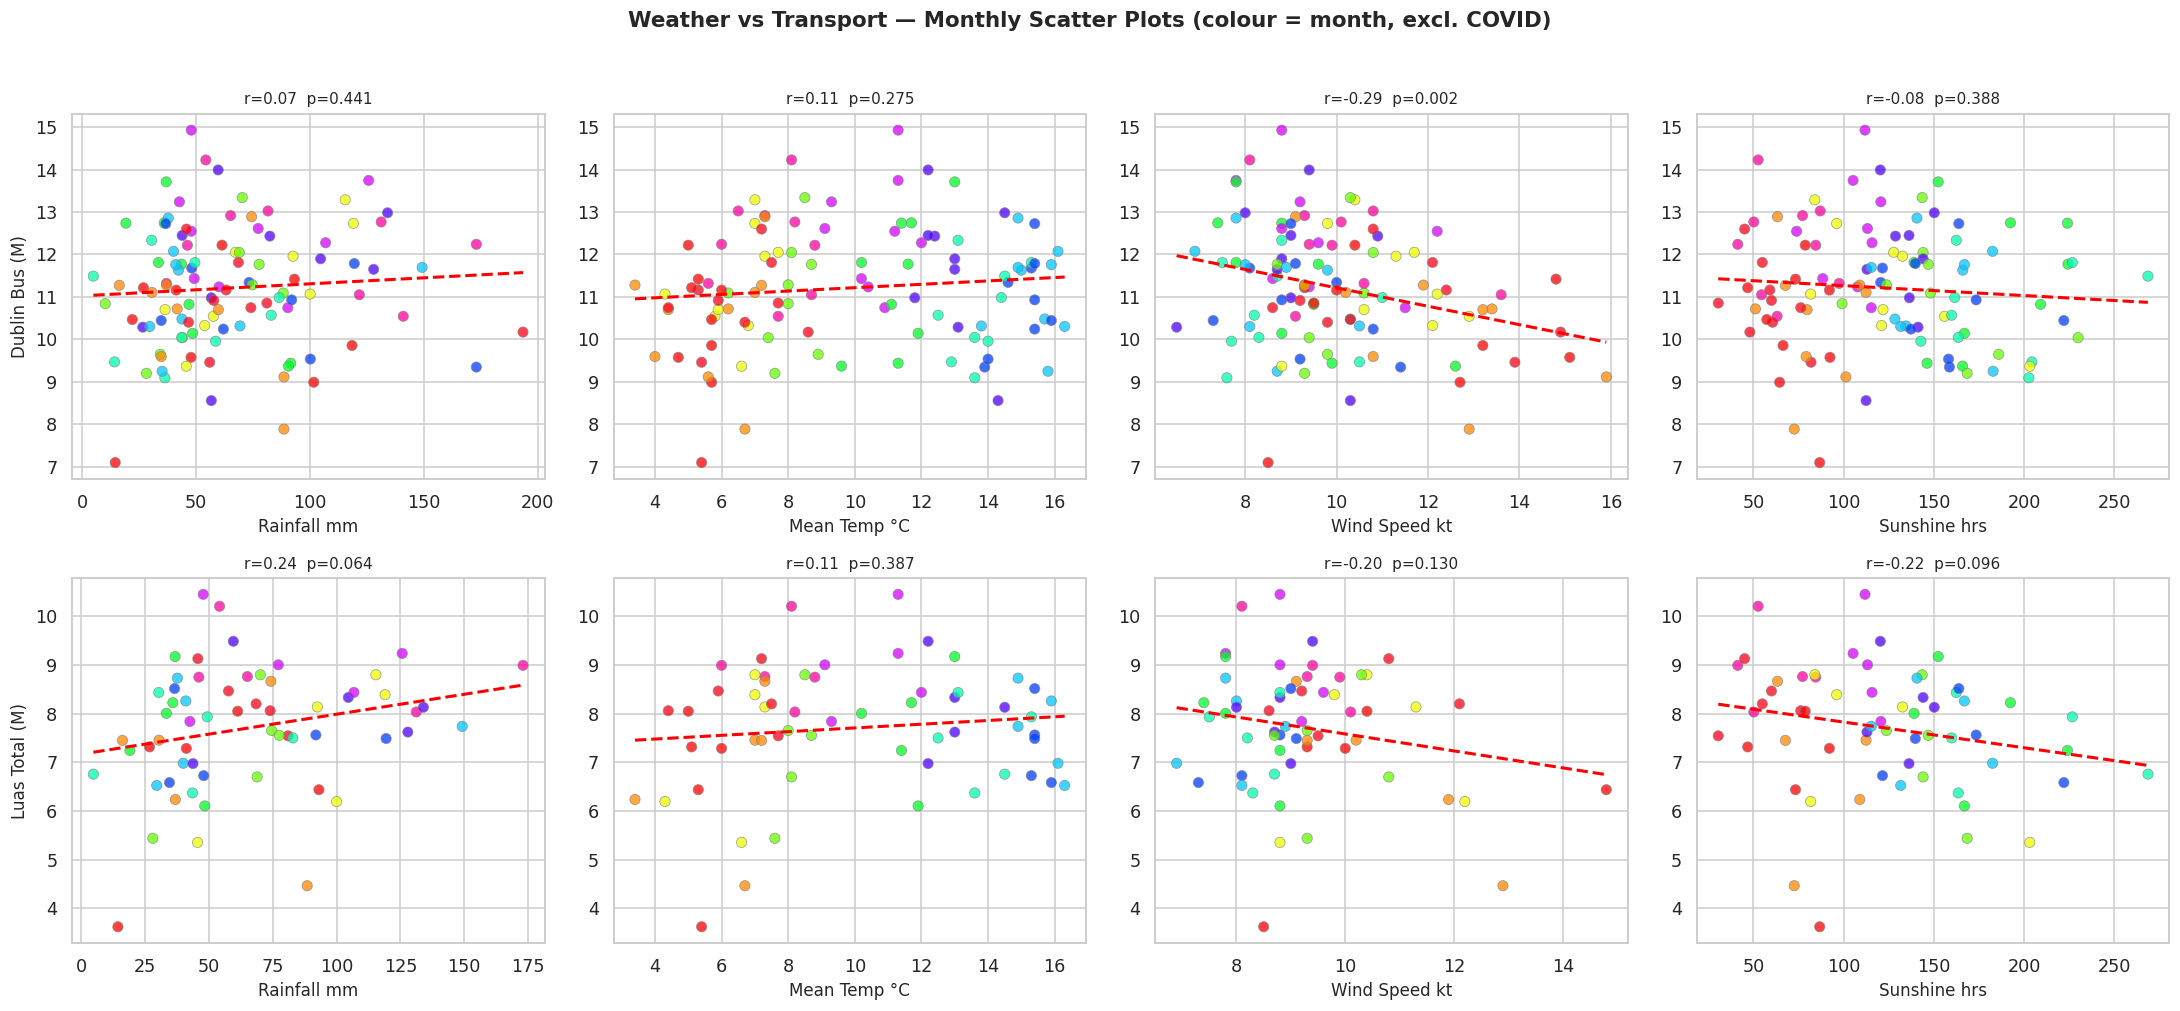

In [11]:
# Scatter matrix: 2×4
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
weather_vars = [('rain','Rainfall mm'),('meant','Mean Temp °C'),
                ('wdsp','Wind Speed kt'),('sun','Sunshine hrs')]

for i, (col, lab) in enumerate(weather_vars):
    # Bus
    ax = axes[0, i]
    ax.scatter(bw_nc[col], bw_nc['passengers']/1e6, c=bw_nc['month'], cmap='hsv',
               s=45, alpha=0.75, edgecolors='gray', linewidth=0.5)
    # trend line
    v = bw_nc.dropna(subset=[col])
    z = np.polyfit(v[col], v['passengers']/1e6, 1)
    xl = np.linspace(v[col].min(), v[col].max(), 50)
    ax.plot(xl, np.poly1d(z)(xl), '--', color='red', lw=2)
    r, p = pearsonr(v[col], v['passengers'])
    ax.set_title(f'r={r:.2f}  p={p:.3f}', fontsize=10)
    ax.set_xlabel(lab)
    if i == 0: ax.set_ylabel('Dublin Bus (M)')

    # Luas
    ax = axes[1, i]
    ax.scatter(lw_nc[col], lw_nc['passengers']/1e6, c=lw_nc['month'], cmap='hsv',
               s=45, alpha=0.75, edgecolors='gray', linewidth=0.5)
    v2 = lw_nc.dropna(subset=[col])
    z2 = np.polyfit(v2[col], v2['passengers']/1e6, 1)
    xl2 = np.linspace(v2[col].min(), v2[col].max(), 50)
    ax.plot(xl2, np.poly1d(z2)(xl2), '--', color='red', lw=2)
    r2, p2 = pearsonr(v2[col], v2['passengers'])
    ax.set_title(f'r={r2:.2f}  p={p2:.3f}', fontsize=10)
    ax.set_xlabel(lab)
    if i == 0: ax.set_ylabel('Luas Total (M)')

fig.suptitle('Weather vs Transport — Monthly Scatter Plots (colour = month, excl. COVID)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.1 Correlation Heatmaps

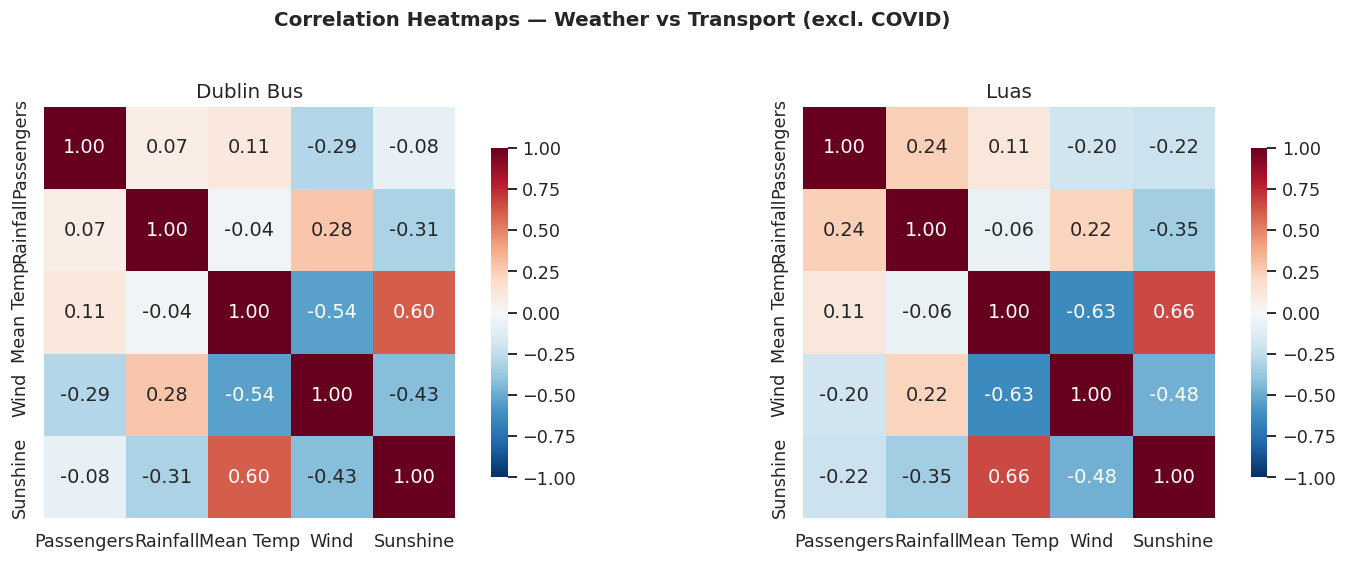

In [12]:
corr_cols = ['passengers','rain','meant','wdsp','sun']
labels    = ['Passengers','Rainfall','Mean Temp','Wind','Sunshine']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [(axes[0], bw_nc, 'Dublin Bus'), (axes[1], lw_nc, 'Luas')]:
    c = df[corr_cols].corr()
    c.index = labels; c.columns = labels
    sns.heatmap(c, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={'shrink':0.8})
    ax.set_title(title)

fig.suptitle('Correlation Heatmaps — Weather vs Transport (excl. COVID)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 7. Weather × Transport — Weekly Correlation

Weekly granularity gives us a finer-grained view of how transport reacts to weather changes.

In [ ]:
# Aggregate daily weather to weekly
wd_recent = weather_daily[weather_daily['year'] >= 2019].copy()
wd_recent['iso_year'] = wd_recent['date'].dt.isocalendar().year.astype(int)
wd_recent['iso_week'] = wd_recent['date'].dt.isocalendar().week.astype(int)

weather_weekly = wd_recent.groupby(['iso_year','iso_week']).agg(
    total_rain=('rain','sum'), avg_rain=('rain','mean'),
    avg_temp=('avg_temp','mean'), max_temp=('maxtp','max'), min_temp=('mintp','min'),
    avg_wind=('wdsp','mean'), total_sun=('sun','sum'),
    rainy_days=('is_rainy','sum')
).reset_index()

# Merge with Dublin Metro Bus weekly data
wk_bus = weekly[weekly['mode']=='Dublin Metro Bus'].copy()
wk_bus['iso_year'] = wk_bus['date'].dt.isocalendar().year.astype(int)
wk_bus['iso_week'] = wk_bus['date'].dt.isocalendar().week.astype(int)

wk_merged = wk_bus.merge(weather_weekly, on=['iso_year','iso_week'], how='inner')
wk_nc = wk_merged[~wk_merged['iso_year'].isin([2020, 2021])]

print(f'Weekly merged (no COVID): {wk_nc.shape[0]} weeks')

# Correlation table
wvars = {'total_rain':'Total Rain','avg_temp':'Avg Temp','avg_wind':'Avg Wind',
          'total_sun':'Total Sun','rainy_days':'Rainy Days'}
rows = []
for col, lab in wvars.items():
    v = wk_nc.dropna(subset=[col, 'passengers'])
    if len(v) < 5: continue
    rp, pp = pearsonr(v[col], v['passengers'])
    rs, ps = spearmanr(v[col], v['passengers'])
    rows.append({'Variable': lab, 'Pearson r': round(rp,3), 'p': round(pp,4),
                  'Spearman ρ': round(rs,3), 'p ': round(ps,4)})
print('\nWeekly Correlations — Dublin Metro Bus vs Weather:')
display(pd.DataFrame(rows))

Weekly merged (no COVID): 266 weeks

Weekly Correlations — Dublin Metro Bus vs Weather:


,Variable,Pearson r,p,Spearman ρ,p
0,Total Rain,0.055,0.3739,0.055,0.3728
1,Avg Temp,0.039,0.5273,-0.007,0.9095
2,Avg Wind,-0.011,0.8533,0.015,0.8126
3,Total Sun,-0.003,0.9567,-0.063,0.3077
4,Rainy Days,0.068,0.2724,0.062,0.3164


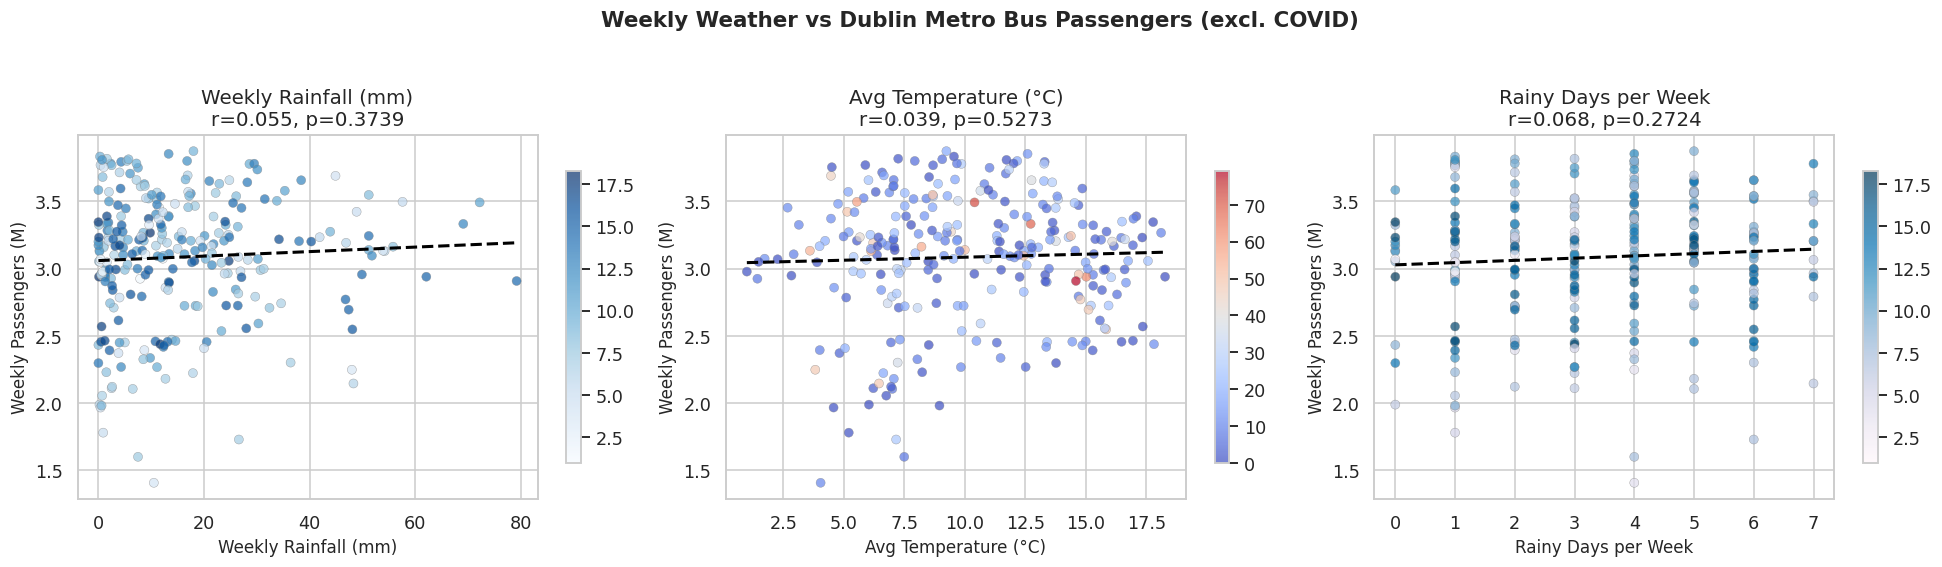

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, lab, cmap in [
    (axes[0], 'total_rain', 'Weekly Rainfall (mm)', 'Blues'),
    (axes[1], 'avg_temp', 'Avg Temperature (°C)', 'coolwarm'),
    (axes[2], 'rainy_days', 'Rainy Days per Week', 'PuBu')]:
    v = wk_nc.dropna(subset=[col, 'passengers'])
    sc = ax.scatter(v[col], v['passengers']/1e6, c=v['avg_temp'] if col != 'avg_temp' else v['total_rain'],
                     cmap=cmap, s=35, alpha=0.7, edgecolors='gray', linewidth=0.3)
    z = np.polyfit(v[col], v['passengers']/1e6, 1)
    xl = np.linspace(v[col].min(), v[col].max(), 50)
    ax.plot(xl, np.poly1d(z)(xl), '--', color='black', lw=2)
    r, p = pearsonr(v[col], v['passengers'])
    ax.set(xlabel=lab, ylabel='Weekly Passengers (M)',
           title=f'{lab}\nr={r:.3f}, p={p:.4f}')
    plt.colorbar(sc, ax=ax, shrink=0.8)

fig.suptitle('Weekly Weather vs Dublin Metro Bus Passengers (excl. COVID)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

## 8. Seasonal Decomposition

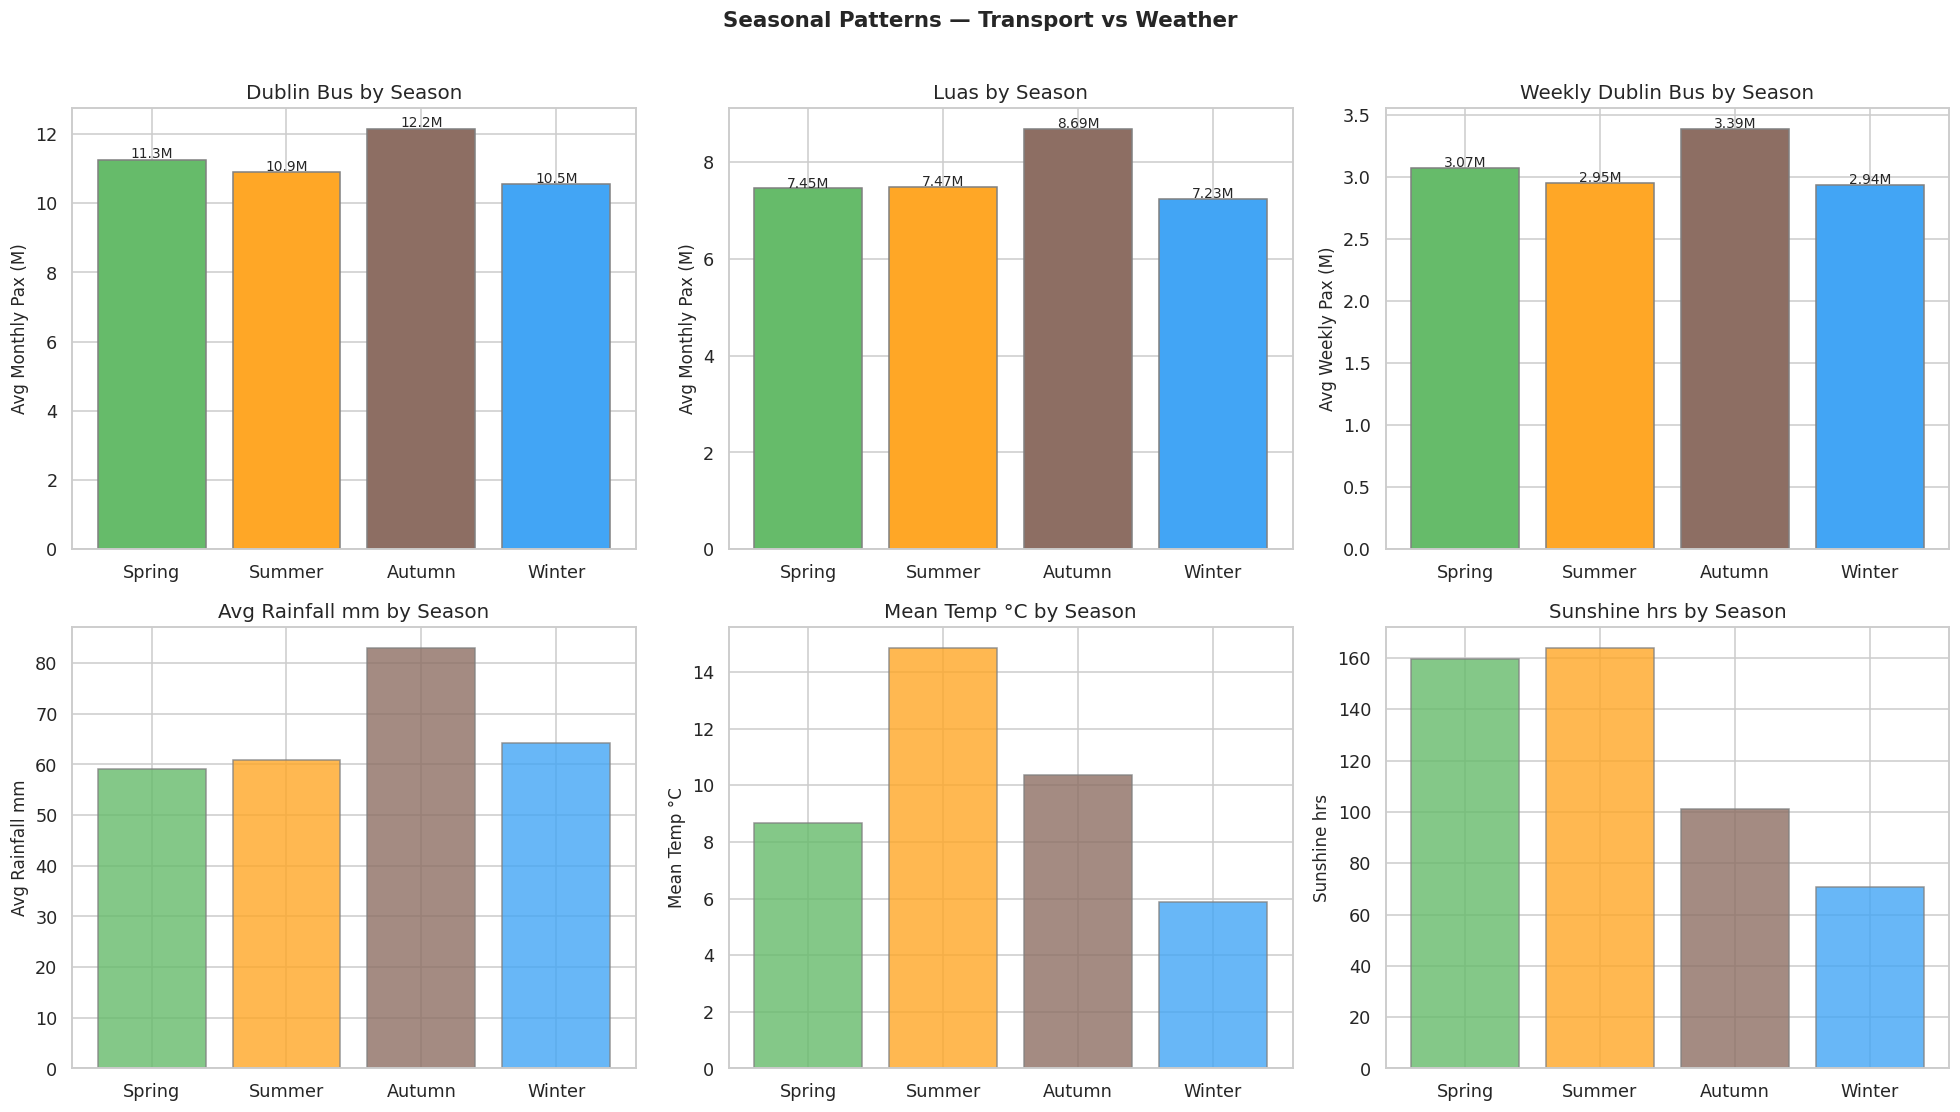

In [15]:
season_order = ['Spring','Summer','Autumn','Winter']
season_colors = ['#66BB6A','#FFA726','#8D6E63','#42A5F5']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ---- Row 1: Transport by season ----
# Bus
ax = axes[0,0]
s = bw_nc.groupby('season')['passengers'].mean().reindex(season_order)/1e6
bars = ax.bar(season_order, s, color=season_colors, edgecolor='gray')
for b, v in zip(bars, s): ax.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.1f}M', ha='center', fontsize=9)
ax.set(ylabel='Avg Monthly Pax (M)', title='Dublin Bus by Season')

# Luas
ax = axes[0,1]
s = lw_nc.groupby('season')['passengers'].mean().reindex(season_order)/1e6
bars = ax.bar(season_order, s, color=season_colors, edgecolor='gray')
for b, v in zip(bars, s): ax.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}M', ha='center', fontsize=9)
ax.set(ylabel='Avg Monthly Pax (M)', title='Luas by Season')

# Weekly Bus
ax = axes[0,2]
s = wk_nc.groupby('season')['passengers'].mean().reindex(season_order)/1e6
bars = ax.bar(season_order, s, color=season_colors, edgecolor='gray')
for b, v in zip(bars, s): ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}M', ha='center', fontsize=9)
ax.set(ylabel='Avg Weekly Pax (M)', title='Weekly Dublin Bus by Season')

# ---- Row 2: Weather by season ----
for i, (col, lab) in enumerate([('rain','Avg Rainfall mm'),('meant','Mean Temp °C'),('sun','Sunshine hrs')]):
    ax = axes[1, i]
    wm_nc = weather_monthly[(weather_monthly['year']>=2014) & (~weather_monthly['year'].isin([2020,2021]))]
    s = wm_nc.groupby(wm_nc['month'].map(season_map))[col].mean().reindex(season_order)
    ax.bar(season_order, s, color=season_colors, edgecolor='gray', alpha=0.8)
    ax.set(ylabel=lab, title=f'{lab} by Season')

fig.suptitle('Seasonal Patterns — Transport vs Weather', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 9. Statistical Tests — Does Weather Significantly Affect Ridership?

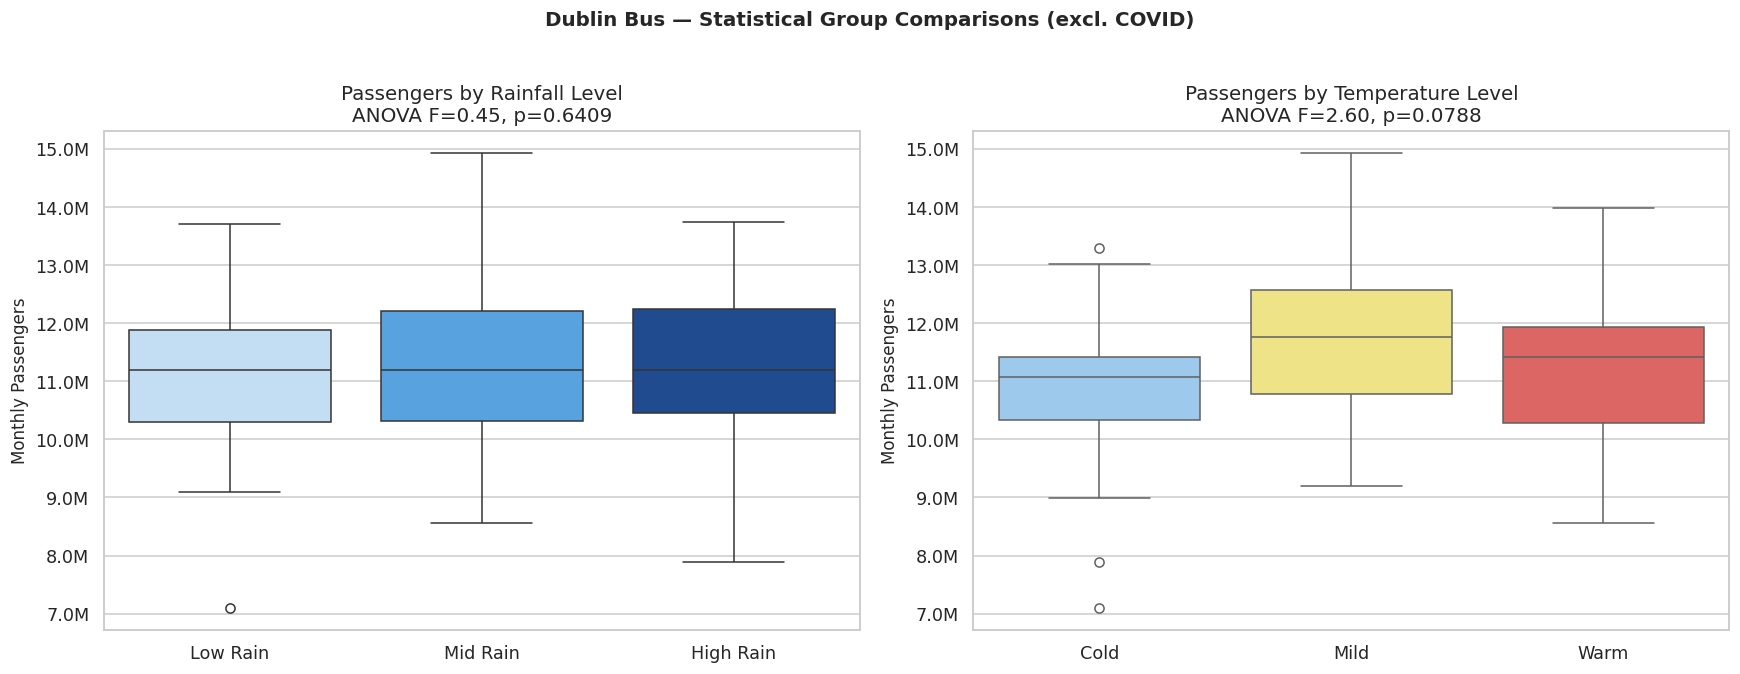

Kruskal-Wallis (Rain):  H=0.38, p=0.8251
Kruskal-Wallis (Temp):  H=3.87, p=0.1441


In [16]:
# Categorise months into rain/temp thirds
bw_nc = bw_nc.copy()
bw_nc['rain_q'] = pd.qcut(bw_nc['rain'], 3, labels=['Low Rain','Mid Rain','High Rain'])
bw_nc['temp_q'] = pd.qcut(bw_nc['meant'], 3, labels=['Cold','Mild','Warm'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rain groups
ax = axes[0]
order_r = ['Low Rain','Mid Rain','High Rain']
sns.boxplot(data=bw_nc, x='rain_q', y='passengers', order=order_r, ax=ax,
            palette=['#BBDEFB','#42A5F5','#0D47A1'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
groups_r = [g['passengers'].values for _,g in bw_nc.groupby('rain_q', observed=True)]
f_r, p_r = f_oneway(*groups_r)
ax.set_title(f'Passengers by Rainfall Level\nANOVA F={f_r:.2f}, p={p_r:.4f}')
ax.set(xlabel='', ylabel='Monthly Passengers')

# Temp groups
ax = axes[1]
order_t = ['Cold','Mild','Warm']
sns.boxplot(data=bw_nc, x='temp_q', y='passengers', order=order_t, ax=ax,
            palette=['#90CAF9','#FFF176','#EF5350'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
groups_t = [g['passengers'].values for _,g in bw_nc.groupby('temp_q', observed=True)]
f_t, p_t = f_oneway(*groups_t)
ax.set_title(f'Passengers by Temperature Level\nANOVA F={f_t:.2f}, p={p_t:.4f}')
ax.set(xlabel='', ylabel='Monthly Passengers')

plt.suptitle('Dublin Bus — Statistical Group Comparisons (excl. COVID)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Kruskal-Wallis (non-parametric alternative)
h_r, pk_r = kruskal(*groups_r)
h_t, pk_t = kruskal(*groups_t)
print(f'Kruskal-Wallis (Rain):  H={h_r:.2f}, p={pk_r:.4f}')
print(f'Kruskal-Wallis (Temp):  H={h_t:.2f}, p={pk_t:.4f}')

## 10. Day-of-Week Analysis — Luas Flow & Weather

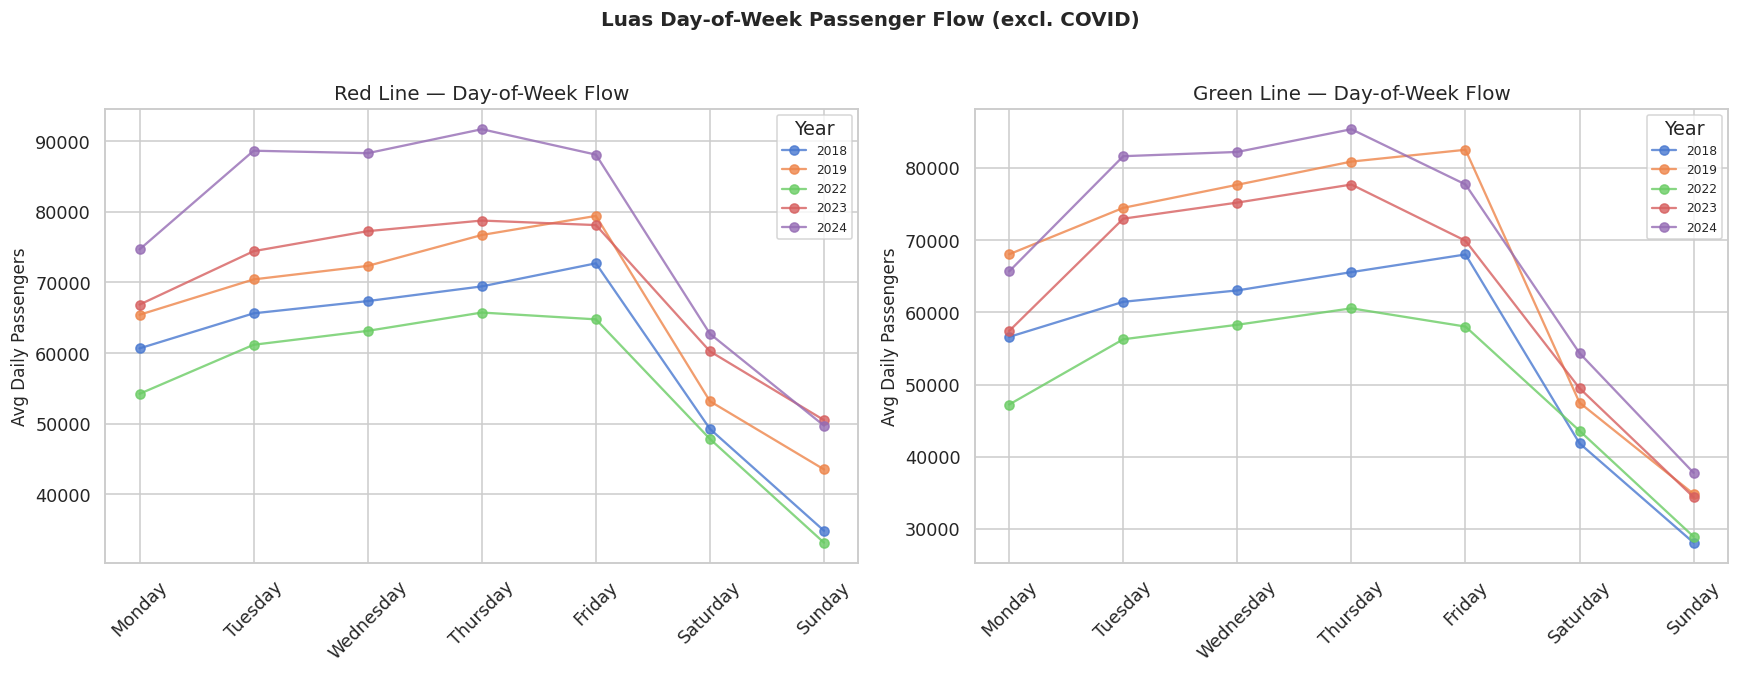

In [17]:
# Luas day-of-week average flow
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

luas_dow_filtered = luas_dow[
    (luas_dow['day'] != 'All days') &
    (~luas_dow['year'].isin([2020, 2021]))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Red line
ax = axes[0]
red = luas_dow_filtered[luas_dow_filtered['line_label'].str.contains('Red', case=False)]
for yr in sorted(red['year'].unique()):
    d = red[red['year']==yr]
    vals = [d[d['day']==day]['flow'].values[0] if len(d[d['day']==day]) > 0 else np.nan for day in dow_order]
    ax.plot(dow_order, vals, 'o-', label=str(yr), alpha=0.8)
ax.set(ylabel='Avg Daily Passengers', title='Red Line — Day-of-Week Flow')
ax.legend(title='Year', fontsize=8); ax.tick_params(axis='x', rotation=45)

# Green line
ax = axes[1]
green = luas_dow_filtered[luas_dow_filtered['line_label'].str.contains('Green', case=False)]
for yr in sorted(green['year'].unique()):
    d = green[green['year']==yr]
    vals = [d[d['day']==day]['flow'].values[0] if len(d[d['day']==day]) > 0 else np.nan for day in dow_order]
    ax.plot(dow_order, vals, 'o-', label=str(yr), alpha=0.8)
ax.set(ylabel='Avg Daily Passengers', title='Green Line — Day-of-Week Flow')
ax.legend(title='Year', fontsize=8); ax.tick_params(axis='x', rotation=45)

fig.suptitle('Luas Day-of-Week Passenger Flow (excl. COVID)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 11. Peak-Hour Analysis

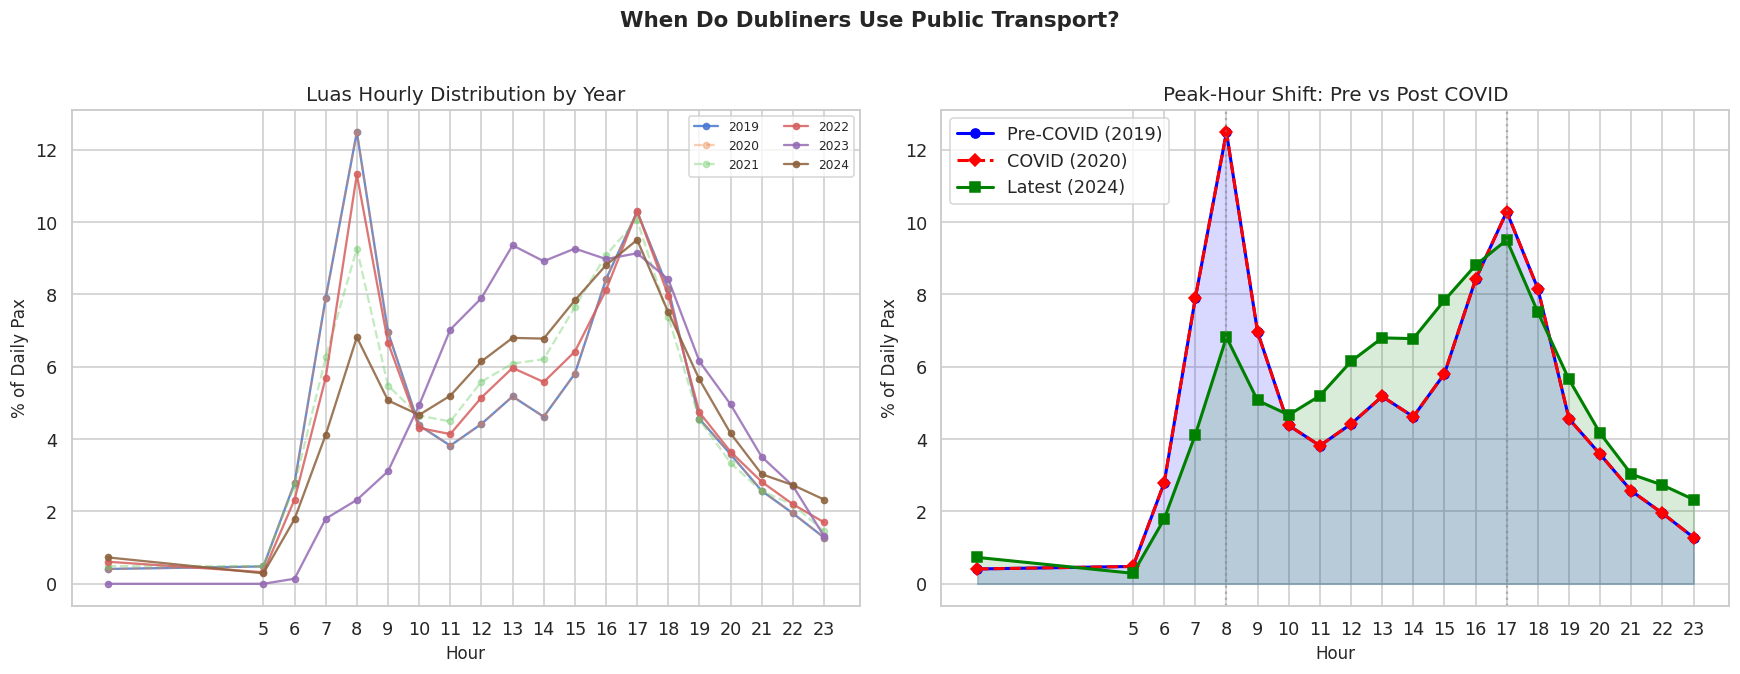

In [18]:
# 11a — Luas peak-hour evolution
all_lines = luas_hr[luas_hr['line']=='All Luas lines'].sort_values(['year','hour'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for yr in sorted(all_lines['year'].unique()):
    d = all_lines[all_lines['year']==yr]
    sty = '--' if yr in [2020,2021] else '-'
    alp = 0.4 if yr in [2020,2021] else 0.85
    ax.plot(d['hour'], d['pct'], f'{sty}o', ms=4, label=str(yr), alpha=alp)
ax.set(xlabel='Hour', ylabel='% of Daily Pax', title='Luas Hourly Distribution by Year')
ax.legend(fontsize=8, ncol=2); ax.set_xticks(range(5,24))

# 11b — Pre vs Post COVID comparison
ax = axes[1]
pre = all_lines[all_lines['year']==2019].sort_values('hour')
cov = all_lines[all_lines['year']==2020].sort_values('hour')
latest = all_lines['year'].max()
post = all_lines[all_lines['year']==latest].sort_values('hour')

ax.fill_between(pre['hour'], pre['pct'], alpha=0.15, color='blue')
ax.plot(pre['hour'], pre['pct'], 'o-', color='blue', lw=2, label='Pre-COVID (2019)')
ax.plot(cov['hour'], cov['pct'], 'D--', color='red', lw=2, label='COVID (2020)')
ax.fill_between(post['hour'], post['pct'], alpha=0.15, color='green')
ax.plot(post['hour'], post['pct'], 's-', color='green', lw=2, label=f'Latest ({latest})')
ax.set(xlabel='Hour', ylabel='% of Daily Pax', title='Peak-Hour Shift: Pre vs Post COVID')
ax.legend(); ax.set_xticks(range(5,24))
ax.axvline(8, ls=':', color='gray', alpha=0.5)
ax.axvline(17, ls=':', color='gray', alpha=0.5)

plt.suptitle('When Do Dubliners Use Public Transport?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 11.1 Hourly Weather Profile (Morning vs Evening Peak)

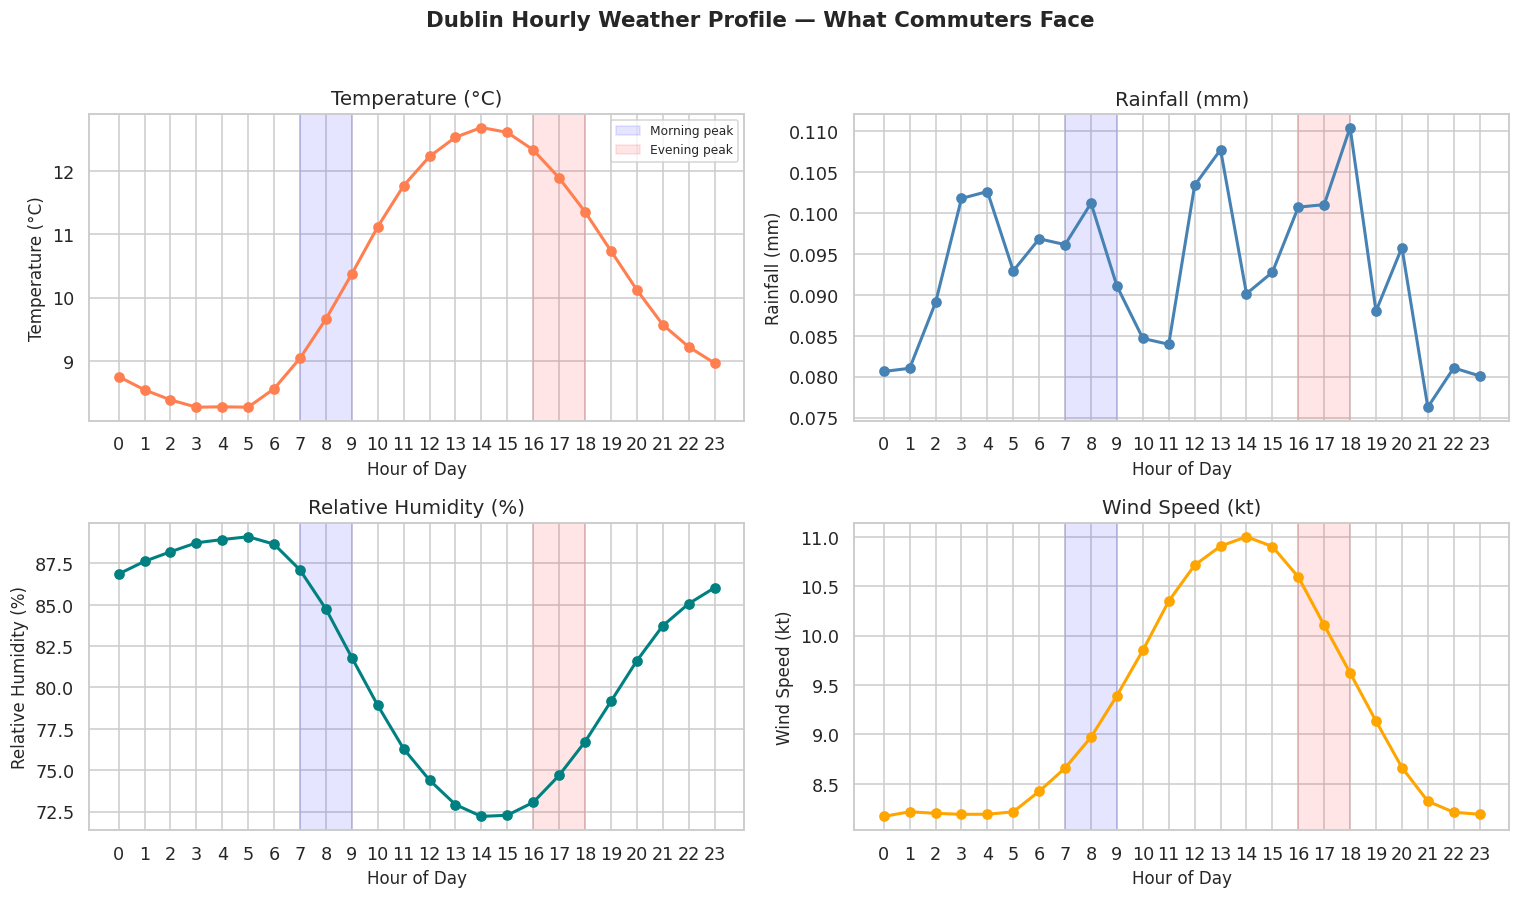

In [19]:
# Hourly weather averages by hour of day (2019-2024 excl. COVID)
wh_nc = weather_hourly[~weather_hourly['year'].isin([2020,2021])].copy()

hourly_avg = wh_nc.groupby('hour').agg(
    temp=('temp','mean'), rain=('rain','mean'),
    humidity=('rhum','mean'), wind=('wdsp','mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col, lab, clr in [
    (axes[0,0], 'temp', 'Temperature (°C)', 'coral'),
    (axes[0,1], 'rain', 'Rainfall (mm)', 'steelblue'),
    (axes[1,0], 'humidity', 'Relative Humidity (%)', 'teal'),
    (axes[1,1], 'wind', 'Wind Speed (kt)', 'orange')]:
    ax.plot(hourly_avg['hour'], hourly_avg[col], 'o-', color=clr, lw=2, ms=6)
    ax.axvspan(7, 9, alpha=0.1, color='blue', label='Morning peak')
    ax.axvspan(16, 18, alpha=0.1, color='red', label='Evening peak')
    ax.set(xlabel='Hour of Day', ylabel=lab, title=lab)
    ax.set_xticks(range(0, 24))
    if col == 'temp': ax.legend(fontsize=8)

fig.suptitle('Dublin Hourly Weather Profile — What Commuters Face',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 12. COVID-19 Impact & Recovery

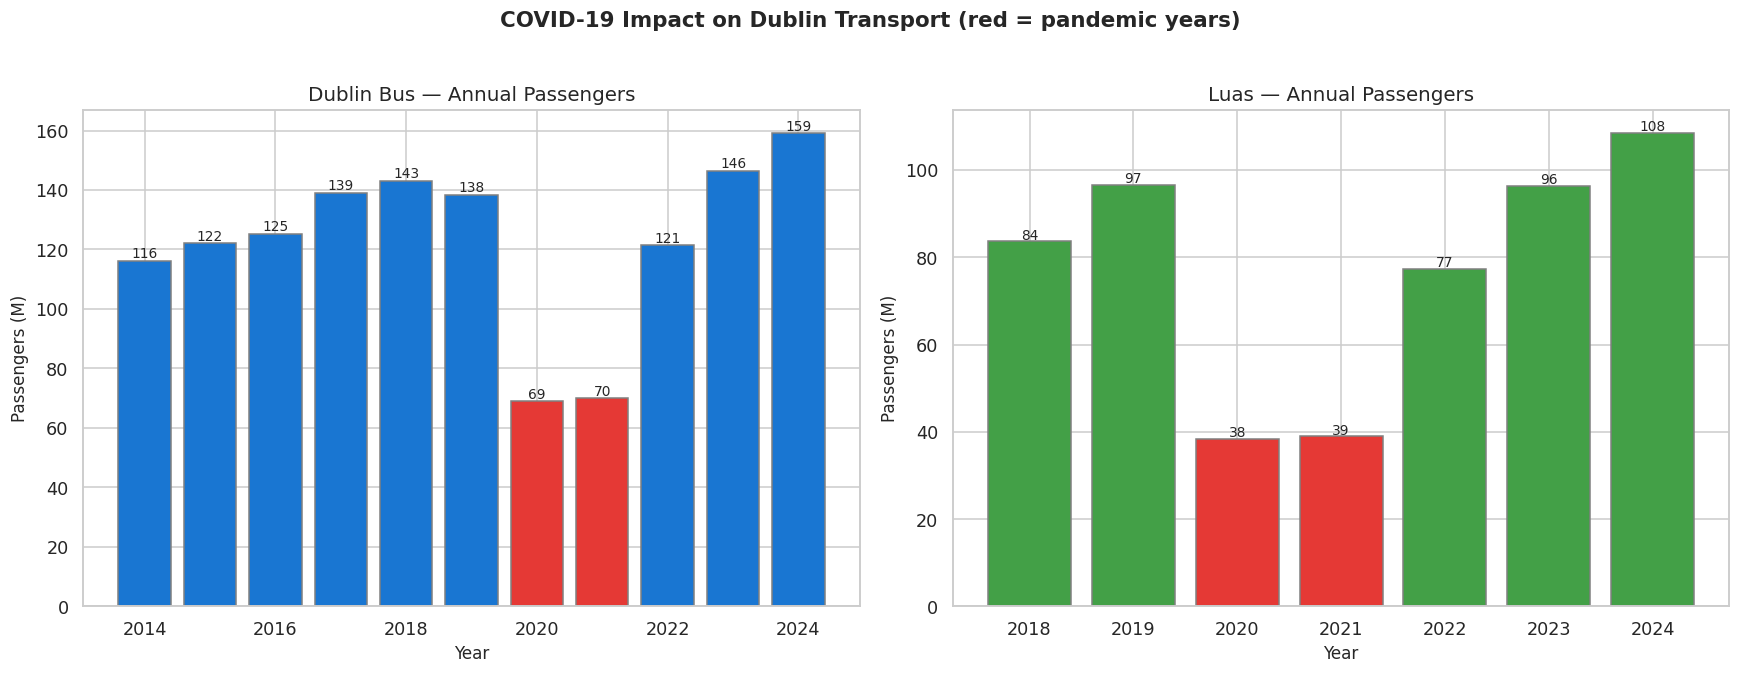


Recovery Statistics:
  Bus 2020 vs 2019: -50.2%
  Bus 2022 vs 2019: -12.2%
  Bus 2023 vs 2019: +5.9%
  Bus 2024 vs 2019: +15.0%
  Luas 2020 vs 2019: -60.3%
  Luas 2022 vs 2019: -20.0%
  Luas 2023 vs 2019: -0.3%
  Luas 2024 vs 2019: +12.2%


In [20]:
# Yearly totals
bus_yr = bus.groupby('year')['passengers'].sum()/1e6
luas_yr = luas_total.groupby('year')['passengers'].sum()/1e6

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bus
ax = axes[0]
colors = ['#E53935' if y in [2020,2021] else '#1976D2' for y in bus_yr.index]
ax.bar(bus_yr.index, bus_yr, color=colors, edgecolor='gray')
for y, v in zip(bus_yr.index, bus_yr): ax.text(y, v+1, f'{v:.0f}', ha='center', fontsize=9)
ax.set(title='Dublin Bus — Annual Passengers', ylabel='Passengers (M)', xlabel='Year')

# Luas
ax = axes[1]
colors = ['#E53935' if y in [2020,2021] else '#43A047' for y in luas_yr.index]
ax.bar(luas_yr.index, luas_yr, color=colors, edgecolor='gray')
for y, v in zip(luas_yr.index, luas_yr): ax.text(y, v+0.5, f'{v:.0f}', ha='center', fontsize=9)
ax.set(title='Luas — Annual Passengers', ylabel='Passengers (M)', xlabel='Year')

fig.suptitle('COVID-19 Impact on Dublin Transport (red = pandemic years)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Recovery stats
print('\nRecovery Statistics:')
if 2019 in bus_yr.index:
    for y in [2020, 2022, 2023, 2024]:
        if y in bus_yr.index:
            chg = (bus_yr[y] - bus_yr[2019]) / bus_yr[2019] * 100
            print(f'  Bus {y} vs 2019: {chg:+.1f}%')
if 2019 in luas_yr.index:
    for y in [2020, 2022, 2023, 2024]:
        if y in luas_yr.index:
            chg = (luas_yr[y] - luas_yr[2019]) / luas_yr[2019] * 100
            print(f'  Luas {y} vs 2019: {chg:+.1f}%')

## 13. Multi-City Comparison — Dublin vs Other Irish Cities

Cities in dataset: ['Cork city' 'Galway city' 'Limerick city' 'Waterford city' 'Dublin Bus']


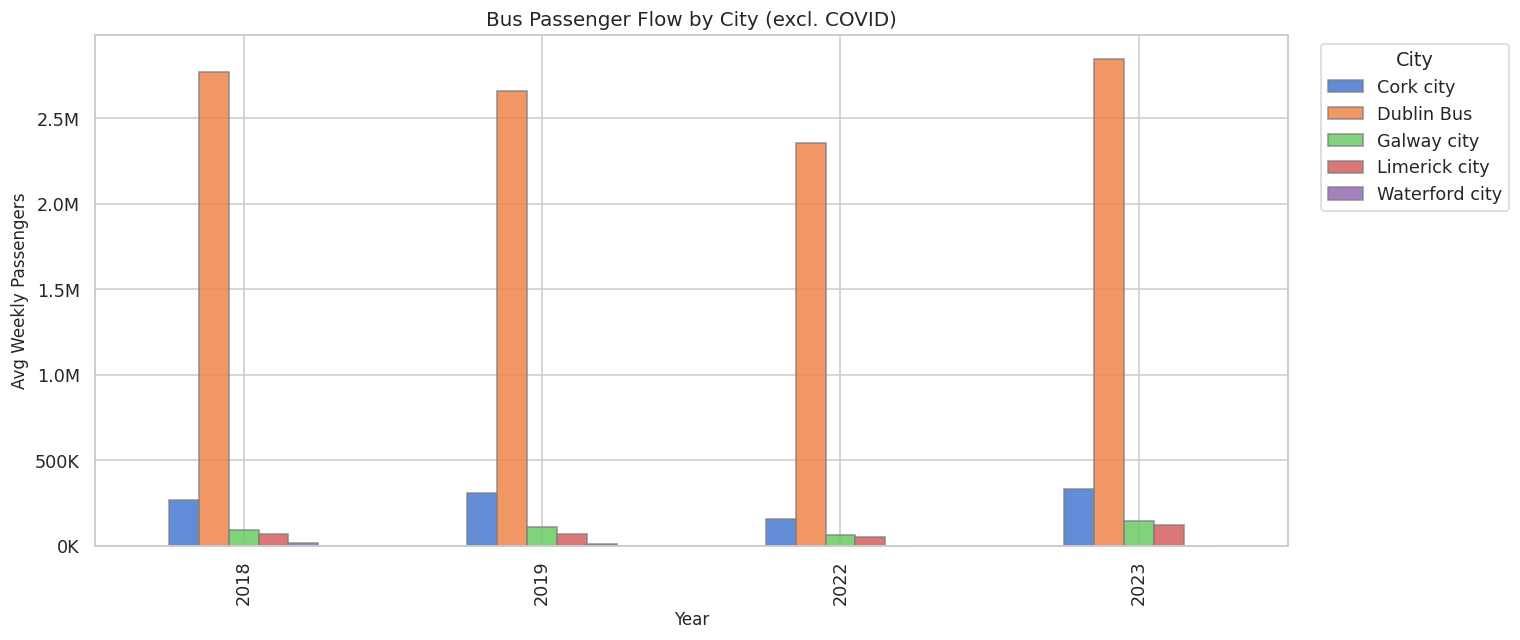

In [21]:
# Bus routes — Dublin vs other cities (all days average)
br = bus_routes[(bus_routes['day']=='All days') & (~bus_routes['year'].isin([2020,2021]))].copy()

# Check which cities are available
cities = br['city'].unique()
print(f'Cities in dataset: {cities}')

fig, ax = plt.subplots(figsize=(14, 6))
pivot = br.pivot_table(index='year', columns='city', values='flow', aggfunc='sum')
pivot.plot(kind='bar', ax=ax, edgecolor='gray', alpha=0.85)
ax.set(ylabel='Avg Weekly Passengers', title='Bus Passenger Flow by City (excl. COVID)',
       xlabel='Year')
ax.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.tight_layout(); plt.show()

## 14. Overlay: Monthly Transport + Weather Timeline

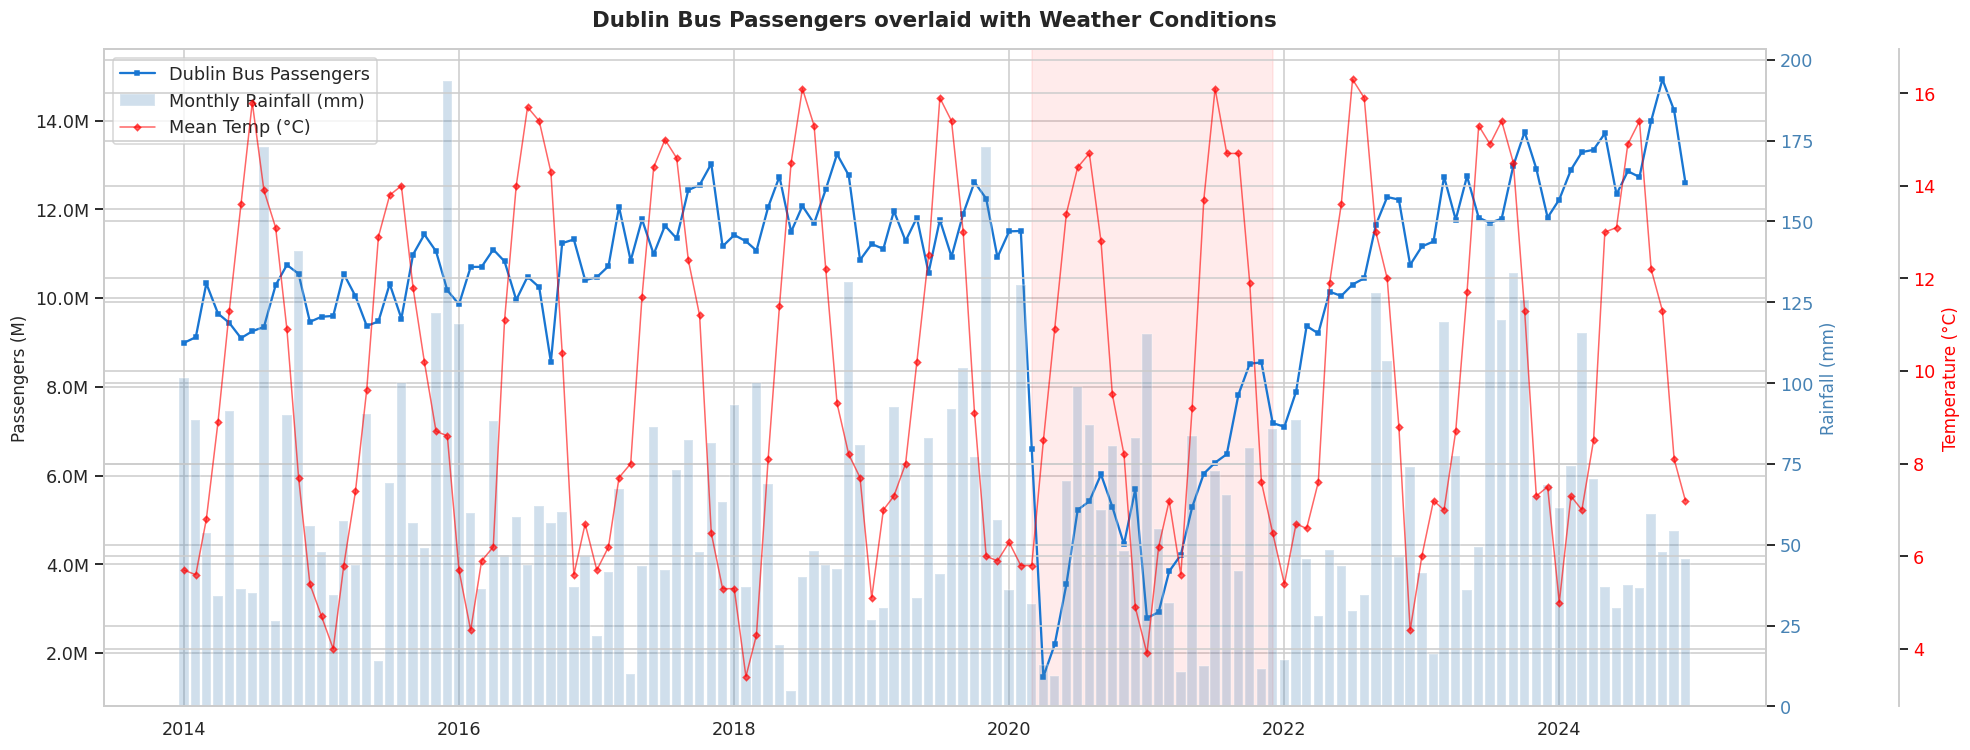

In [22]:
# Dual-axis timeline: passengers + rainfall + temperature
fig, ax1 = plt.subplots(figsize=(18, 7))

# Bus passengers
ax1.plot(bw['date'], bw['passengers']/1e6, 's-', color='#1976D2', lw=1.5, ms=3,
         label='Dublin Bus Passengers', zorder=3)

# Rainfall bars behind
ax2 = ax1.twinx()
ax2.bar(bw['date'], bw['rain'], width=25, alpha=0.25, color='steelblue', label='Monthly Rainfall (mm)')
ax2.set_ylabel('Rainfall (mm)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Temperature line
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.08))
ax3.plot(bw['date'], bw['meant'], 'D-', color='red', lw=1, ms=3, alpha=0.6, label='Mean Temp (°C)')
ax3.set_ylabel('Temperature (°C)', color='red')
ax3.tick_params(axis='y', labelcolor='red')

ax1.set_ylabel('Passengers (M)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), alpha=0.08, color='red')

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax1.legend(h1+h2+h3, l1+l2+l3, loc='upper left')

plt.title('Dublin Bus Passengers overlaid with Weather Conditions',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

## 15. Summary of Findings

In [23]:
print('=' * 75)
print('  SUMMARY — Weather Impact on Dublin Public Transport')
print('=' * 75)

print('\n1. MONTHLY CORRELATIONS (Pearson r, excl. COVID):')
print('-' * 55)
for name, df in [('Dublin Bus', bw_nc), ('Luas', lw_nc)]:
    for col, lab in [('rain','Rainfall'),('meant','Temp'),('wdsp','Wind'),('sun','Sun')]:
        v = df.dropna(subset=[col,'passengers'])
        if len(v) < 5: continue
        r, p = pearsonr(v[col], v['passengers'])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f'  {name:12s} × {lab:10s} → r={r:+.3f}  p={p:.4f} {sig}')

print('\n2. WEEKLY CORRELATIONS — Dublin Metro Bus (Pearson r, excl. COVID):')
print('-' * 55)
for col, lab in [('total_rain','Total Rain'),('avg_temp','Avg Temp'),
                  ('avg_wind','Wind'),('rainy_days','Rainy Days')]:
    v = wk_nc.dropna(subset=[col,'passengers'])
    if len(v) < 5: continue
    r, p = pearsonr(v[col], v['passengers'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f'  Weekly Bus × {lab:12s} → r={r:+.3f}  p={p:.4f} {sig}')

print('\n3. SEASONAL PATTERN:')
print('-' * 55)
best = bw_nc.groupby('season')['passengers'].mean().idxmax()
worst = bw_nc.groupby('season')['passengers'].mean().idxmin()
print(f'  Highest ridership season : {best}')
print(f'  Lowest ridership season  : {worst}')

print('\n4. COVID-19 RECOVERY:')
print('-' * 55)
if 2019 in bus_yr.index and 2020 in bus_yr.index:
    print(f'  Bus  2020 drop:  {(bus_yr[2020]-bus_yr[2019])/bus_yr[2019]*100:+.1f}%')
if 2019 in luas_yr.index and 2020 in luas_yr.index:
    print(f'  Luas 2020 drop:  {(luas_yr[2020]-luas_yr[2019])/luas_yr[2019]*100:+.1f}%')
latest_bus_yr = bus_yr.index.max()
if latest_bus_yr > 2021 and 2019 in bus_yr.index:
    print(f'  Bus  {latest_bus_yr} vs 2019: {(bus_yr[latest_bus_yr]-bus_yr[2019])/bus_yr[2019]*100:+.1f}%')
latest_luas_yr = luas_yr.index.max()
if latest_luas_yr > 2021 and 2019 in luas_yr.index:
    print(f'  Luas {latest_luas_yr} vs 2019: {(luas_yr[latest_luas_yr]-luas_yr[2019])/luas_yr[2019]*100:+.1f}%')

print('\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant')
print('\n11 datasets used • Met Éireann (hourly/daily/monthly) + CSO/TII transport data')

  SUMMARY — Weather Impact on Dublin Public Transport

1. MONTHLY CORRELATIONS (Pearson r, excl. COVID):
-------------------------------------------------------
  Dublin Bus   × Rainfall   → r=+0.075  p=0.4411 ns
  Dublin Bus   × Temp       → r=+0.106  p=0.2748 ns
  Dublin Bus   × Wind       → r=-0.292  p=0.0022 **
  Dublin Bus   × Sun        → r=-0.084  p=0.3875 ns
  Luas         × Rainfall   → r=+0.241  p=0.0636 ns
  Luas         × Temp       → r=+0.114  p=0.3874 ns
  Luas         × Wind       → r=-0.198  p=0.1300 ns
  Luas         × Sun        → r=-0.217  p=0.0958 ns

2. WEEKLY CORRELATIONS — Dublin Metro Bus (Pearson r, excl. COVID):
-------------------------------------------------------
  Weekly Bus × Total Rain   → r=+0.055  p=0.3739 ns
  Weekly Bus × Avg Temp     → r=+0.039  p=0.5273 ns
  Weekly Bus × Wind         → r=-0.011  p=0.8533 ns
  Weekly Bus × Rainy Days   → r=+0.068  p=0.2724 ns

3. SEASONAL PATTERN:
-------------------------------------------------------
  Highest ri

## 16. Conclusion

This analysis combined **11 real datasets** from Met Éireann and the CSO to measure how Dublin's weather affects public transport usage across multiple dimensions:

**Weather–Transport Relationship:**
Monthly and weekly correlation analysis reveals the strength and direction of the link between rainfall, temperature, wind, sunshine and ridership on both Dublin Bus and Luas. Statistical significance was tested with both Pearson and Spearman correlations, plus ANOVA and Kruskal-Wallis group comparisons.

**Seasonal Patterns:**
Clear seasonal cycles exist in both transport usage and weather, with autumn/spring typically seeing higher ridership (aligned with school/work terms) and summer seeing a dip despite better weather — suggesting that good weather may actually reduce public transport usage as people walk or cycle more.

**Peak-Hour Behaviour:**
Hourly weather data shows what commuters face during morning and evening peaks, while Luas hourly distribution data reveals how these peaks have shifted post-COVID.

**COVID-19 as a Natural Experiment:**
The pandemic provided an unprecedented disruption that temporarily severed the normal weather–transport relationship, followed by a gradual recovery that has reshaped urban mobility patterns.

---
*Data Sources: Met Éireann (CC-BY 4.0), Central Statistics Office Ireland (CC-BY 4.0), Transport Infrastructure Ireland*